In [1]:
# =============================================================================
# IMPORTS Y CONFIGURACIÓN
# =============================================================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import json
import gc
import psutil
import os
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import PCA
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuración para plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 7)

# Paths
RAW_DIR = Path("../data/raw/cluvi/")
OUTPUT_DIR = "../data/process/"  # Adaptado si es necesario
REPORT_DIR = Path("../reports/eda_cluvi/")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print("EDA COMPLETO Y MEJORADO - DATASET CLUVI (MENÚS Y CATEGORÍAS)")
print("="*80)

EDA COMPLETO Y MEJORADO - DATASET CLUVI (MENÚS Y CATEGORÍAS)


In [2]:
# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================

def save_report(data, filename, format='json'):
    """Guarda reportes en formato JSON o CSV"""
    filepath = REPORT_DIR / filename
    if format == 'json':
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
    elif format == 'csv' and isinstance(data, (pl.DataFrame, pd.DataFrame)):
        if isinstance(data, pl.DataFrame):
            data.write_csv(filepath)
        else:
            data.to_csv(filepath, index=False)
    print(f"✓ Reporte guardado: {filepath}")

def plot_and_save(fig, filename):
    """Guarda figura y la muestra"""
    filepath = REPORT_DIR / filename
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"✓ Gráfico guardado: {filepath}")
    plt.show()

def calculate_gini(counts):
    """Calcula el coeficiente de Gini para medir desbalance"""
    sorted_counts = np.sort(counts)
    n = len(counts)
    cumsum = np.cumsum(sorted_counts)
    return (2 * np.sum((np.arange(1, n+1)) * sorted_counts)) / (n * cumsum[-1]) - (n + 1) / n

def print_section(title):
    """Imprime encabezado de sección"""
    print("\n" + "="*80)
    print(f"{title}")
    print("="*80)

def liberar_ram():
    """Libera RAM y muestra uso actual"""
    process = psutil.Process(os.getpid())
    mem_antes = process.memory_info().rss / 1024 / 1024  # MB
    
    # Colectar garbage
    gc.collect()
    
    mem_despues = process.memory_info().rss / 1024 / 1024
    print(f"RAM liberada: {mem_antes - mem_despues:.2f} MB")
    print(f"RAM actual: {mem_despues:.2f} MB")

In [3]:
!pwd

/home/daniel-linux/Tesis/Recolectar_Datos/notebooks


In [4]:
# =============================================================================
# CARGA DE DATOS (concatenando todos los CSVs)
# =============================================================================
print_section("CARGA DE DATOS (Todos los CSVs en ../data/raw/CLuvi/)")

import glob
import os

print(f"pwd {os.getcwd()}")

csv_files = sorted(glob.glob(str(RAW_DIR / "*.csv")))
print(f"Intentando cargar archivos CSV desde: {RAW_DIR}")
if not csv_files:
    print(f"✗ No se encontraron archivos CSV en {RAW_DIR}")
    # Diagnóstico: ¿existe el archivo específico?
    test_file = RAW_DIR / "dimproducts_ES_EN.csv"
    if test_file.exists():
        print(f"¡El archivo {test_file} SÍ existe! Pero glob no lo encontró. Revisa mayúsculas/minúsculas en la ruta o extensión.")
    else:
        print(f"El archivo {test_file} NO existe según os.path.exists().")
    print("Por favor, verifica que la ruta y los archivos existan antes de continuar.")
    # Salida temprana: no hay datos, DataFrame vacío para evitar errores posteriores
    df = pl.DataFrame()
else:
    print(f"Archivos CSV encontrados: {len(csv_files)}")
    for f in csv_files:
        print(f"  - {f}")

    # Leer y concatenar todos los CSVs encontrados
    dfs = []
    for f in csv_files:
        try:
            df_tmp = pl.read_csv(f, separator=";", infer_schema_length=10000)
            dfs.append(df_tmp)
        except Exception as e:
            print(f"Error al leer {f}: {e}")

    if not dfs:
        print("✗ No se pudo cargar ningún archivo CSV.")
        df = pl.DataFrame()
    else:
        df_full = pl.concat(dfs, how="vertical", rechunk=True)
        print(f"✓ DataFrame concatenado: {df_full.shape}")

        # Seleccionar columnas relevantes y limpiar (incluyendo las nuevas columnas)
        df = df_full.select([
            pl.col("label").str.to_lowercase().str.strip_chars().alias("label"),
            pl.col("standard_label").str.to_lowercase().str.strip_chars().alias("standard_label"),
            pl.col("description").str.to_lowercase().str.strip_chars().alias("description"),
            pl.col("category").str.to_lowercase().str.strip_chars().alias("category"),
            pl.col("main_category").str.to_lowercase().str.strip_chars().alias("main_category"),
            pl.col("is_alcoholic"),  # Nueva columna
            pl.col("type_product").str.to_lowercase().str.strip_chars().alias("type_product"),  # Nueva columna, asumiendo que es string
            pl.col("country_code").str.to_uppercase().alias("country_code")  # Nueva columna, asumiendo códigos en mayúsculas
        ]).with_columns([
            pl.col("description").str.len_chars().alias("description_length_chars"),
            pl.col("label").str.len_chars().alias("label_length_chars"),
            pl.col("standard_label").str.len_chars().alias("standard_label_length_chars"),
            pl.col("label").str.to_lowercase().str.strip_chars().alias("label_lower"),
            pl.col("standard_label").str.to_lowercase().str.strip_chars().alias("standard_label_lower"),
            pl.col("description").str.to_lowercase().str.strip_chars().alias("description_lower"),
            pl.col("description").str.split(" ").list.len().alias("num_words_description"),
            pl.col("description").str.contains(r"\d").alias("has_numbers"),
            pl.col("description").str.contains(r"[^a-zA-Z0-9\s]").alias("has_special_chars")
        ])

        # Filtrar filas con label no nulo (asumiendo es clave primaria)
        df = df.filter(pl.col("label").is_not_null())

        print(f"✓ DataFrame final: {df.shape}")
        print(f"Columnas: {df.columns}")

        # Sample si es muy grande (1/2.5 para consistencia)
        if df.height > 10000:
            df = df.sample(n=int(df.height), seed=42)
            print(f"✓ Muestra: {df.shape}")


CARGA DE DATOS (Todos los CSVs en ../data/raw/CLuvi/)
pwd /home/daniel-linux/Tesis/Recolectar_Datos/notebooks
Intentando cargar archivos CSV desde: ../data/raw/cluvi
Archivos CSV encontrados: 1
  - ../data/raw/cluvi/dimproducts_ES_EN.csv
✓ DataFrame concatenado: (736181, 8)
✓ DataFrame final: (736181, 17)
Columnas: ['label', 'standard_label', 'description', 'category', 'main_category', 'is_alcoholic', 'type_product', 'country_code', 'description_length_chars', 'label_length_chars', 'standard_label_length_chars', 'label_lower', 'standard_label_lower', 'description_lower', 'num_words_description', 'has_numbers', 'has_special_chars']
✓ Muestra: (736181, 17)


In [5]:
# =============================================================================
# SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES
# =============================================================================
print_section("SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES")

quality_report = {}

# 1.1 Valores nulos
print("\n--- Valores Nulos ---")
null_counts = df.null_count()
print(null_counts)
quality_report['null_counts'] = {col: int(null_counts[col][0]) for col in null_counts.columns}

# 1.2 Duplicados
print("\n--- Duplicados ---")
duplicates = df.filter(pl.col("label").is_duplicated())
print(f"Labels duplicados: {len(duplicates)} ({100*len(duplicates)/len(df):.2f}%)")
quality_report['duplicates'] = len(duplicates)

if len(duplicates) > 0:
    print("\nEjemplos de duplicados (top 5):")
    print(duplicates.head(5).select(["label", "standard_label", "category"]))

# 1.3 Inconsistencias: label vs standard_label
print("\n--- Inconsistencias Label vs Standard_Label ---")
inconsistencies = df.filter(pl.col("label") != pl.col("standard_label"))
print(f"Labels que difieren de standard_label: {len(inconsistencies)} ({100*len(inconsistencies)/len(df):.2f}%)")
quality_report['label_inconsistencies'] = len(inconsistencies)

if len(inconsistencies) > 0:
    print("\nTop 10 ejemplos:")
    print(inconsistencies.head(10).select(["label", "standard_label", "category"]))

# 1.4 Inconsistencias en categorías (misma label, diferente category)
print("\n--- Inconsistencias de Categorías ---")
cat_conflicts = df.group_by("label").agg([
    pl.col("category").n_unique().alias("num_categories"),
    pl.col("category").alias("categories")
]).filter(pl.col("num_categories") > 1).sort("num_categories", descending=True)

print(f"Labels con múltiples categorías: {len(cat_conflicts)}")
quality_report['ambiguous_categories'] = len(cat_conflicts)

if len(cat_conflicts) > 0:
    print("\nTop 10 labels ambiguos:")
    print(cat_conflicts.head(10))
    save_report(cat_conflicts.to_pandas(), 'ambiguous_categories.csv', 'csv')

# 1.5 Longitudes inválidas
invalid_lengths = df.filter(
    (pl.col("label_length_chars") <= 0) | 
    (pl.col("description_length_chars") <= 0)
)
print(f"Entradas con longitud inválida: {len(invalid_lengths)}")
quality_report['invalid_lengths'] = len(invalid_lengths)

# 1.6 Validaciones para nuevas columnas
print("\n--- Validaciones para Columnas Nuevas (is_alcoholic, type_product, country_code) ---")
# Por ejemplo, valores únicos y conteos para type_product y country_code
unique_type_product = df['type_product'].n_unique()
unique_country_code = df['country_code'].n_unique()
print(f"Tipos de productos únicos: {unique_type_product}")
print(f"Códigos de países únicos: {unique_country_code}")

# Porcentaje de alcohólicos
if 'is_alcoholic' in df.columns:
    alcoholic_pct = df.filter(pl.col("is_alcoholic") == True).height / df.height * 100
    print(f"Porcentaje de productos alcohólicos: {alcoholic_pct:.2f}%")
    quality_report['alcoholic_pct'] = alcoholic_pct

# Conteos para type_product
type_product_dist = df["type_product"].value_counts().sort("count", descending=True)
print("Distribución de type_product (top 10):")
print(type_product_dist.head(10))
quality_report['unique_type_product'] = unique_type_product

# Conteos para country_code
country_code_dist = df["country_code"].value_counts().sort("count", descending=True)
print("Distribución de country_code (top 10):")
print(country_code_dist.head(10))
quality_report['unique_country_code'] = unique_country_code

# Guardar reporte de calidad
save_report(quality_report, 'quality_report.json')


SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES

--- Valores Nulos ---
shape: (1, 17)
┌───────┬────────────┬────────────┬──────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ label ┆ standard_l ┆ descriptio ┆ category ┆ … ┆ descriptio ┆ num_words_ ┆ has_numbe ┆ has_speci │
│ ---   ┆ abel       ┆ n          ┆ ---      ┆   ┆ n_lower    ┆ descriptio ┆ rs        ┆ al_chars  │
│ u32   ┆ ---        ┆ ---        ┆ u32      ┆   ┆ ---        ┆ n          ┆ ---       ┆ ---       │
│       ┆ u32        ┆ u32        ┆          ┆   ┆ u32        ┆ ---        ┆ u32       ┆ u32       │
│       ┆            ┆            ┆          ┆   ┆            ┆ u32        ┆           ┆           │
╞═══════╪════════════╪════════════╪══════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 0     ┆ 0          ┆ 0          ┆ 0        ┆ … ┆ 0          ┆ 0          ┆ 0         ┆ 0         │
└───────┴────────────┴────────────┴──────────┴───┴────────────┴────────────┴───────────┴───────────┘

--- Dupl

In [6]:
# =============================================================================
# SECCIÓN 2: VALIDACIÓN DE CATEGORÍAS Y MAIN_CATEGORIES
# =============================================================================
print_section("SECCIÓN 2: VALIDACIÓN DE CATEGORÍAS")

category_report = {}

# 2.1 Consistencia category vs main_category
print("\n--- Validación de Consistencia Categoría vs Main_Category ---")
cat_main_consistency = df.filter(pl.col("category") != pl.col("main_category"))
print(f"Categorías que difieren de main_category: {len(cat_main_consistency)} ({100*len(cat_main_consistency)/len(df):.2f}%)")
category_report['category_inconsistencies'] = len(cat_main_consistency)

if len(cat_main_consistency) > 0:
    print("\nTop 10 ejemplos:")
    print(cat_main_consistency.head(10).select(["label", "category", "main_category"]))

# 2.2 Cobertura de categorías (cuántas entradas por categoría)
print("\n--- Cobertura por Categoría ---")
cat_coverage = df.group_by("category").agg([
    pl.count().alias("num_entries"),
    pl.col("description_length_chars").mean().alias("avg_desc_length")
]).sort("num_entries", descending=True)

print("Top 10 categorías por cobertura:")
print(cat_coverage.head(10))

category_report['category_stats'] = {
    'num_categories': len(cat_coverage),
    'mean_entries_per_cat': float(cat_coverage["num_entries"].mean()),
    'max_entries_per_cat': int(cat_coverage["num_entries"].max())
}

# 2.3 Cobertura por columnas nuevas
print("\n--- Cobertura por Type_Product ---")
type_product_coverage = df.group_by("type_product").agg([
    pl.count().alias("num_entries")
]).sort("num_entries", descending=True)
print("Top 10 type_product por cobertura:")
print(type_product_coverage.head(10))

print("\n--- Cobertura por Country_Code ---")
country_code_coverage = df.group_by("country_code").agg([
    pl.count().alias("num_entries")
]).sort("num_entries", descending=True)
print("Top 10 country_code por cobertura:")
print(country_code_coverage.head(10))

print("\n--- Distribución de is_alcoholic por Categoría ---")
alcoholic_by_cat = df.group_by("category").agg([
    pl.col("is_alcoholic").mean().alias("pct_alcoholic")
]).sort("pct_alcoholic", descending=True)
print("Top 10 categorías con mayor porcentaje alcohólico:")
print(alcoholic_by_cat.head(10))

save_report(category_report, 'category_validation_report.json')


SECCIÓN 2: VALIDACIÓN DE CATEGORÍAS

--- Validación de Consistencia Categoría vs Main_Category ---
Categorías que difieren de main_category: 501913 (68.18%)

Top 10 ejemplos:
shape: (10, 3)
┌──────────────────────────────┬─────────────────────────────────┬─────────────────┐
│ label                        ┆ category                        ┆ main_category   │
│ ---                          ┆ ---                             ┆ ---             │
│ str                          ┆ str                             ┆ str             │
╞══════════════════════════════╪═════════════════════════════════╪═════════════════╡
│ juanchito                    ┆ platos con base en plátano ver… ┆ plátano verde   │
│ anago                        ┆ signature                       ┆ sushi           │
│ tanqueray ten                ┆ ginebras                        ┆ no especificado │
│ vaccari nero                 ┆ licores y digestivos            ┆ licores         │
│ champiñones a la chalaca     ┆ piqueos frí

Top 10 categorías por cobertura:
shape: (10, 3)
┌─────────────────┬─────────────┬─────────────────┐
│ category        ┆ num_entries ┆ avg_desc_length │
│ ---             ┆ ---         ┆ ---             │
│ str             ┆ u32         ┆ f64             │
╞═════════════════╪═════════════╪═════════════════╡
│ no especificado ┆ 89195       ┆ 54.57779        │
│ bebidas         ┆ 24897       ┆ 17.622565       │
│ entradas        ┆ 16042       ┆ 88.415098       │
│ cervezas        ┆ 14179       ┆ 27.29043        │
│ postres         ┆ 10716       ┆ 56.773423       │
│ whisky          ┆ 10105       ┆ 33.751509       │
│ ron             ┆ 9082        ┆ 22.933825       │
│ tequila         ┆ 8903        ┆ 29.188813       │
│ cócteles        ┆ 8809        ┆ 49.351345       │
│ licores         ┆ 8676        ┆ 17.238243       │
└─────────────────┴─────────────┴─────────────────┘

--- Cobertura por Type_Product ---
Top 10 type_product por cobertura:
shape: (5, 2)
┌─────────────────┬─────────────┐
│

In [7]:
# =============================================================================
# SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA
# =============================================================================
print_section("SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA")
liberar_ram()
basic_stats = {}

# Totales
total_entries = len(df)
unique_labels = df['label'].n_unique()
unique_categories = df['category'].n_unique()
unique_type_product = df['type_product'].n_unique()
unique_country_code = df['country_code'].n_unique()

print(f"Total entradas: {total_entries:,}")
print(f"Labels únicos: {unique_labels:,}")
print(f"Categorías únicas: {unique_categories:,}")
print(f"Tipos de productos únicos: {unique_type_product:,}")
print(f"Códigos de países únicos: {unique_country_code:,}")

basic_stats['total_entries'] = total_entries
basic_stats['unique_labels'] = unique_labels
basic_stats['unique_categories'] = unique_categories
basic_stats['unique_type_product'] = unique_type_product
basic_stats['unique_country_code'] = unique_country_code

# Cobertura por categoría principal
coverage = df.group_by("main_category").agg(pl.count()).with_columns([
    (pl.col("count") / total_entries * 100).alias("coverage_pct")
]).sort("coverage_pct", descending=True)

print(f"\nCobertura por main_category (top 5):")
print(coverage.head(5))
basic_stats['coverage_top_main_cat'] = coverage.head(5).to_dicts()

# Entradas por categoría
print("\nEntradas por categoría:")
print("¿Qué significa 'entradas por categoría'?")
print("Las 'entradas por categoría' representan la cantidad de registros (filas) que pertenecen a cada categoría específica en el DataFrame. Es decir, para cada categoría, se cuenta cuántos menús (o elementos) están asignados a esa categoría.")
entries_per_cat = df["category"].value_counts().describe()
print(entries_per_cat)

# Análisis de percentiles
print("\n--- Análisis de Percentiles (Entradas por Categoría) ---")
entries_arr = df.group_by("category").agg(pl.count())["count"].to_numpy()
percentiles = [50, 75, 90, 95, 97.5, 99, 99.5, 99.9, 100]
percentile_values = {p: np.percentile(entries_arr, p) for p in percentiles}

for p in percentiles:
    p_value = percentile_values[p]
    cats_above = df.group_by("category").agg(pl.count()).filter(pl.col("count") > p_value)
    print(f"P{p}: {p_value:.1f} entradas | {len(cats_above)} categorías sobre este umbral")

print("""
Explicación:
- Cada 'entrada' es una fila del DataFrame, es decir, un registro individual (por ejemplo, un menú o receta).
- Cada 'categoría' es una etiqueta o grupo al que pueden pertenecer varias entradas.
- El análisis de percentiles muestra, para distintos percentiles (por ejemplo, el percentil 90), cuántas entradas (filas) tiene la categoría que está justo en ese percentil, y cuántas categorías tienen más entradas que ese valor.
- Por ejemplo: Si en P90 dice "14.0 entradas | 2634 categorías sobre este umbral", significa que el 90% de las categorías tienen 14 o menos entradas, y hay 2634 categorías que tienen más de 14 entradas.
- Así puedes ver cuántas categorías son muy grandes (con muchas entradas) y cuántas son pequeñas.
""")

# Categorías extremas
extreme_cats = df.group_by("category").agg(pl.count()).filter(pl.col("count") > percentile_values[99]).sort("count", descending=True)
print(f"\nCategorías en top 1% (>{percentile_values[99]:.0f} entradas): {len(extreme_cats)}")
print("\nTop 10 categorías con más entradas:")
print(extreme_cats.head(10))

# Estadísticas para nuevas columnas
print("\n--- Estadísticas para Columnas Nuevas ---")
basic_stats['alcoholic_count'] = int(df.filter(pl.col("is_alcoholic") == True).height)
basic_stats['type_product_top5'] = type_product_dist.head(5).to_dicts()
basic_stats['country_code_top5'] = country_code_dist.head(5).to_dicts()

save_report(basic_stats, 'basic_stats.json')


SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA
RAM liberada: 0.00 MB
RAM actual: 1417.20 MB
Total entradas: 736,181
Labels únicos: 285,169
Categorías únicas: 20,843
Tipos de productos únicos: 5
Códigos de países únicos: 11

Cobertura por main_category (top 5):
shape: (5, 3)
┌─────────────────┬────────┬──────────────┐
│ main_category   ┆ count  ┆ coverage_pct │
│ ---             ┆ ---    ┆ ---          │
│ str             ┆ u32    ┆ f64          │
╞═════════════════╪════════╪══════════════╡
│ no especificado ┆ 218154 ┆ 29.633202    │
│ bebidas         ┆ 70486  ┆ 9.574548     │
│ licores         ┆ 38230  ┆ 5.193016     │
│ vinos           ┆ 19473  ┆ 2.645138     │
│ entradas        ┆ 12981  ┆ 1.763289     │
└─────────────────┴────────┴──────────────┘

Entradas por categoría:
¿Qué significa 'entradas por categoría'?
Las 'entradas por categoría' representan la cantidad de registros (filas) que pertenecen a cada categoría específica en el DataFrame. Es decir, para cada categoría, se cuenta cu


SECCIÓN 4: DISTRIBUCIÓN DE CATEGORÍAS Y DESBALANCE
RAM liberada: -0.07 MB
RAM actual: 1421.65 MB
Distribución de categorías:
shape: (20_843, 2)
┌─────────────────────────────────┬───────┐
│ category                        ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ no especificado                 ┆ 89195 │
│ bebidas                         ┆ 24897 │
│ entradas                        ┆ 16042 │
│ cervezas                        ┆ 14179 │
│ postres                         ┆ 10716 │
│ …                               ┆ …     │
│ not spicy ceviche               ┆ 1     │
│ sweet ending                    ┆ 1     │
│ pizzas de mariscos de 1 ingred… ┆ 1     │
│ burrotes                        ┆ 1     │
│ helado de nitrógeno             ┆ 1     │
└─────────────────────────────────┴───────┘

--- Métricas de Desbalance ---
Coeficiente de Gini: 0.838 (0=balance perfecto, 1=máximo desbalance)
Entrop

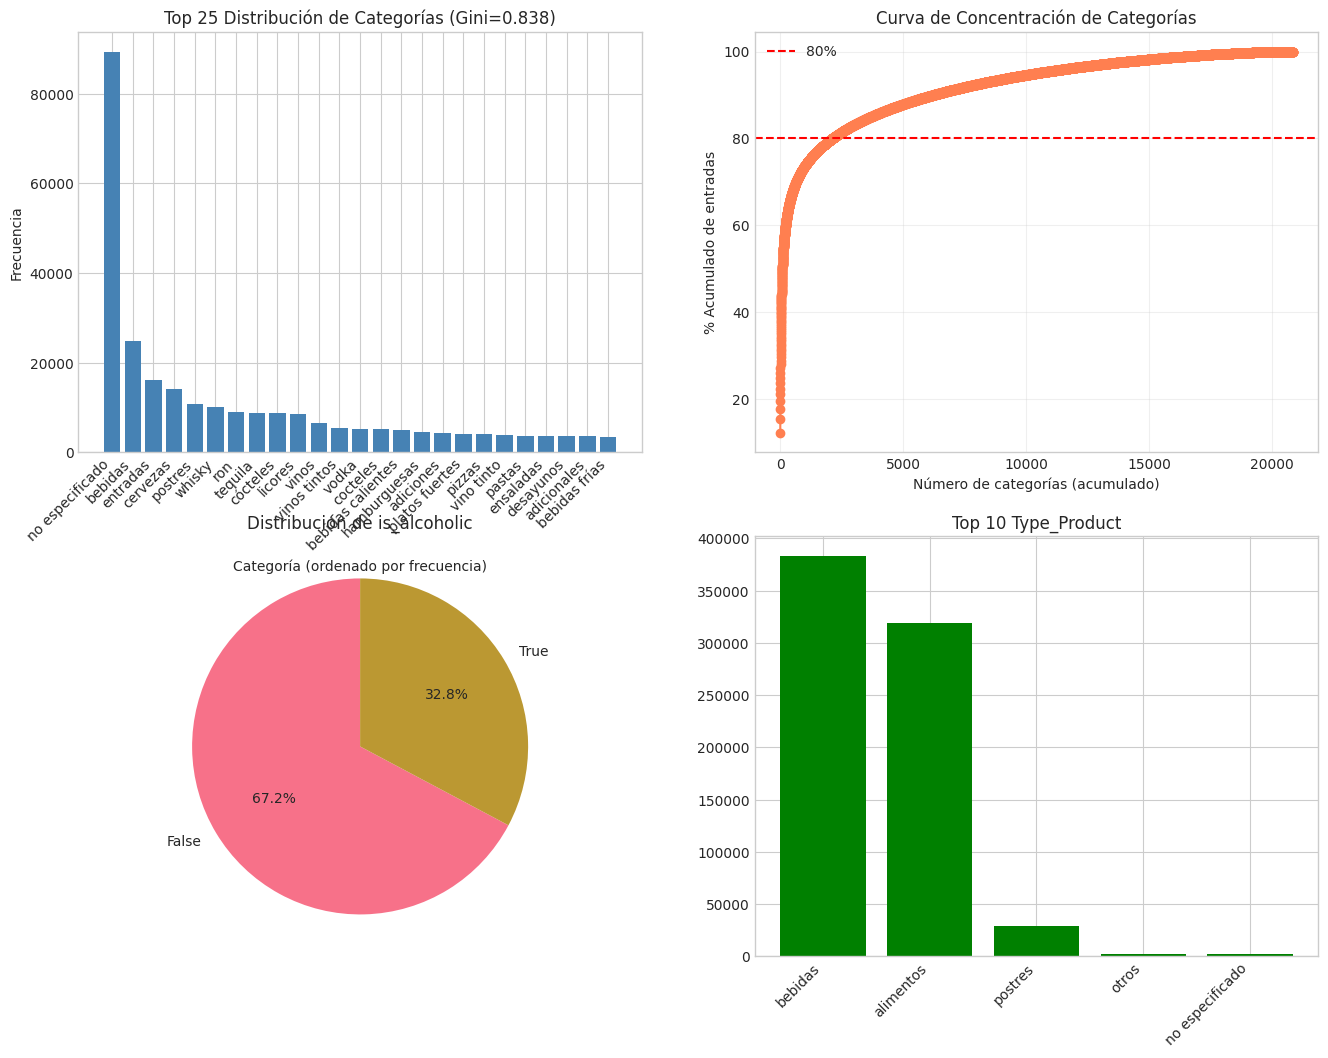

✓ Reporte guardado: ../reports/eda_cluvi/category_stats.json


In [8]:
# =============================================================================
# SECCIÓN 4: DISTRIBUCIÓN DE CATEGORÍAS Y ANÁLISIS DE DESBALANCE
# =============================================================================
print_section("SECCIÓN 4: DISTRIBUCIÓN DE CATEGORÍAS Y DESBALANCE")
liberar_ram()

category_stats = {}

# Distribución de categorías
cat_dist = df["category"].value_counts().sort("count", descending=True)
print("Distribución de categorías:")
print(cat_dist)

# Métricas de desbalance
cat_counts = cat_dist["count"].to_numpy()
gini = calculate_gini(cat_counts)
ent = entropy(cat_counts / cat_counts.sum())
max_ratio = cat_counts.max() / cat_counts.min()

print(f"\n--- Métricas de Desbalance ---")
print(f"Coeficiente de Gini: {gini:.3f} (0=balance perfecto, 1=máximo desbalance)")
print(f"Entropía: {ent:.3f} (mayor=más uniforme)")
print(f"Ratio max/min: {max_ratio:.1f}x")

category_stats['gini_coefficient'] = float(gini)
category_stats['entropy'] = float(ent)
category_stats['max_min_ratio'] = float(max_ratio)
category_stats['num_categories'] = len(cat_dist)

# Categorías raras (< 1% del total)
rare_threshold = 0.01 * total_entries
rare_cats = cat_dist.filter(pl.col("count") < rare_threshold)
print(f"\nCategorías raras (<1% = {rare_threshold:.0f} entradas): {len(rare_cats)}")
if len(rare_cats) > 0:
    print(rare_cats)
category_stats['rare_categories_count'] = len(rare_cats)

# Distribución de main_categories
main_cat_dist = df["main_category"].value_counts().sort("count", descending=True)
print("\nDistribución de main_categories (top 25):")
print(main_cat_dist.head(25))

# Distribución de nuevas columnas
print("\n--- Distribución de Type_Product ---")
type_product_dist = df["type_product"].value_counts().sort("count", descending=True)
print(type_product_dist.head(25))

print("\n--- Distribución de Country_Code ---")
country_code_dist = df["country_code"].value_counts().sort("count", descending=True)
print(country_code_dist.head(25))

print("\n--- Distribución de is_alcoholic ---")
alcoholic_dist = df["is_alcoholic"].value_counts()
print(alcoholic_dist)

# Plot distribución de categorías
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bar plot para el top 25 de categorías
cat_dist_top25_pd = cat_dist.head(25).to_pandas()
axes[0,0].bar(range(len(cat_dist_top25_pd)), cat_dist_top25_pd["count"], color='steelblue')
axes[0,0].set_xlabel("Categoría (ordenado por frecuencia)")
axes[0,0].set_ylabel("Frecuencia")
axes[0,0].set_title(f"Top 25 Distribución de Categorías (Gini={gini:.3f})")
axes[0,0].set_xticks(range(len(cat_dist_top25_pd)))
axes[0,0].set_xticklabels(cat_dist_top25_pd["category"], rotation=45, ha='right')

# Acumulado (usa todas las categorías para la curva de concentración)
cat_dist_pd_full = cat_dist.to_pandas() # Use full distribution for cumulative plot
cumsum = np.cumsum(cat_dist_pd_full["count"]) / cat_dist_pd_full["count"].sum() * 100
axes[0,1].plot(range(len(cumsum)), cumsum, marker='o', color='coral')
axes[0,1].axhline(80, color='red', linestyle='--', label='80%')
axes[0,1].set_xlabel("Número de categorías (acumulado)")
axes[0,1].set_ylabel("% Acumulado de entradas")
axes[0,1].set_title("Curva de Concentración de Categorías")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Pie chart para is_alcoholic
alcoholic_pie = alcoholic_dist.to_pandas()
axes[1,0].pie(alcoholic_pie["count"], labels=alcoholic_pie["is_alcoholic"], autopct='%1.1f%%', startangle=90)
axes[1,0].set_title("Distribución de is_alcoholic")

# Bar para top type_product
type_product_top = type_product_dist.head(10).to_pandas()
axes[1,1].bar(range(len(type_product_top)), type_product_top["count"], color='green')
axes[1,1].set_xticks(range(len(type_product_top)))
axes[1,1].set_xticklabels(type_product_top["type_product"], rotation=45, ha='right')
axes[1,1].set_title("Top 10 Type_Product")

plot_and_save(fig, 'category_distribution.png')

save_report(category_stats, 'category_stats.json')


SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES
RAM liberada: 0.00 MB
RAM actual: 1442.70 MB
Estadísticas de longitud de descripciones (chars):
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 736181.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 54.706465 │
│ std        ┆ 88.21153  │
│ min        ┆ 0.0       │
│ 25%        ┆ 15.0      │
│ 50%        ┆ 19.0      │
│ 75%        ┆ 77.0      │
│ max        ┆ 7997.0    │
└────────────┴───────────┘

Longitud de descripciones por categoría:
shape: (20_843, 7)
┌────────────────────┬─────────────┬───────────────┬─────────────┬────────────┬────────────┬───────┐
│ category           ┆ mean_length ┆ median_length ┆ std_length  ┆ min_length ┆ max_length ┆ count │
│ ---                ┆ ---         ┆ ---           ┆ ---         ┆ ---        ┆ ---        ┆ ---   │
│ str                ┆ f64         ┆ f64           ┆ f64  

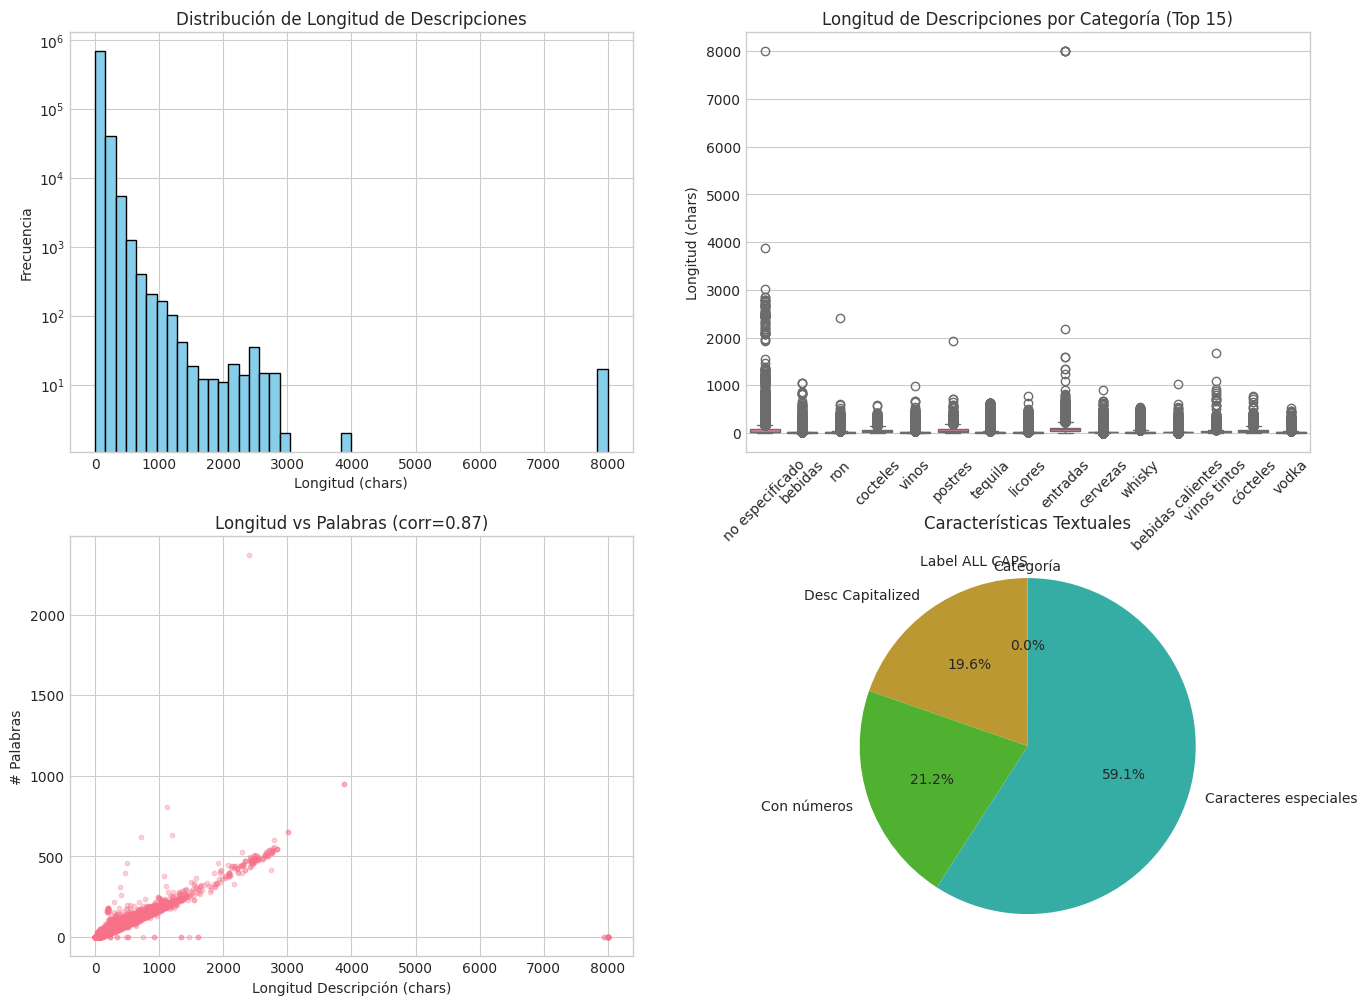

✓ Reporte guardado: ../reports/eda_cluvi/text_analysis.json


In [9]:
# =============================================================================
# SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES
# =============================================================================
print_section("SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES")
liberar_ram()

text_analysis = {}

# Agregar columnas derivadas para características textuales (si no están ya)
df = df.with_columns([
    (pl.col("label") == pl.col("label").str.to_uppercase()).alias("label_all_caps"),
    (pl.col("description").str.slice(0, 1) == pl.col("description").str.slice(0, 1).str.to_uppercase()).alias("desc_capitalized")
])

# Estadísticas de longitud de descripciones
length_stats = df["description_length_chars"].describe()
print("Estadísticas de longitud de descripciones (chars):")
print(length_stats)

# Longitudes por categoría
length_by_cat = df.group_by("category").agg([
    pl.col("description_length_chars").mean().alias("mean_length"),
    pl.col("description_length_chars").median().alias("median_length"),
    pl.col("description_length_chars").std().alias("std_length"),
    pl.col("description_length_chars").min().alias("min_length"),
    pl.col("description_length_chars").max().alias("max_length"),
    pl.count().alias("count")
]).sort("mean_length", descending=True)

print("\nLongitud de descripciones por categoría:")
print(length_by_cat)

# Categorías con mayor variabilidad
print("\nCategorías con mayor variabilidad en longitud (top 5):")
print(length_by_cat.sort("std_length", descending=True).head(5))

# Análisis de características textuales
print("\n--- Características Textuales ---")
caps_stats = df.select([
    pl.col("label_all_caps").sum().alias("label_all_caps"),
    pl.col("desc_capitalized").sum().alias("desc_capitalized"),
    pl.col("has_numbers").sum().alias("with_numbers"),
    pl.col("has_special_chars").sum().alias("with_special_chars")
])
print(caps_stats)

text_analysis['label_all_caps_pct'] = float(100 * caps_stats["label_all_caps"][0] / total_entries)
text_analysis['desc_capitalized_pct'] = float(100 * caps_stats["desc_capitalized"][0] / total_entries)
text_analysis['with_numbers_pct'] = float(100 * caps_stats["with_numbers"][0] / total_entries)
text_analysis['with_special_chars_pct'] = float(100 * caps_stats["with_special_chars"][0] / total_entries)

# Descripciones muy cortas (posibles errores)
very_short = df.filter(pl.col("description_length_chars") <= 10)
print(f"\nDescripciones muy cortas (≤10 chars): {len(very_short)} ({100*len(very_short)/total_entries:.2f}%)")
print("Ejemplos:")
print(very_short.head(10).select(["label", "category", "description_length_chars"]))

# Descripciones muy largas
very_long = df.filter(pl.col("description_length_chars") > 500)
print(f"\nDescripciones muy largas (>500 chars): {len(very_long)}")
if len(very_long) > 0:
    print("Top 5 más largas:")
    print(very_long.sort("description_length_chars", descending=True).head(5).select(["label", "category", "description_length_chars"]))

# Correlación longitud descripción vs num palabras
corr_length_words = df.select([
    pl.corr("description_length_chars", "num_words_description").alias("corr")
]).item()
print(f"\nCorrelación longitud descripción vs # palabras: {corr_length_words:.3f}")
text_analysis['corr_desc_length_num_words'] = float(corr_length_words)

# Análisis textual por columnas nuevas
print("\n--- Características Textuales por Type_Product ---")
text_by_type = df.group_by("type_product").agg([
    pl.col("description_length_chars").mean().alias("avg_desc_length")
]).sort("avg_desc_length", descending=True)
print(text_by_type.head(10))

print("\n--- Características Textuales por Country_Code ---")
text_by_country = df.group_by("country_code").agg([
    pl.col("description_length_chars").mean().alias("avg_desc_length")
]).sort("avg_desc_length", descending=True)
print(text_by_country.head(10))

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histograma de longitudes de descripciones (con escala log)
axes[0,0].hist(df["description_length_chars"].to_numpy(), bins=50, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel("Longitud (chars)")
axes[0,0].set_ylabel("Frecuencia")
axes[0,0].set_title("Distribución de Longitud de Descripciones")
axes[0,0].set_yscale('log')

# Boxplot por categoría (top 15 categorías)
top_15_cats = cat_dist.head(15)["category"].to_list()
data_top15 = df.filter(pl.col("category").is_in(top_15_cats))
sns.boxplot(data=data_top15.to_pandas(), x="category", y="description_length_chars", ax=axes[0,1])
axes[0,1].set_xlabel("Categoría")
axes[0,1].set_ylabel("Longitud (chars)")
axes[0,1].set_title("Longitud de Descripciones por Categoría (Top 15)")
axes[0,1].tick_params(axis='x', rotation=45)

# Scatter: longitud descripción vs # palabras
scatter_data = df.to_pandas()
axes[1,0].scatter(scatter_data["description_length_chars"], scatter_data["num_words_description"], alpha=0.3, s=10)
axes[1,0].set_xlabel("Longitud Descripción (chars)")
axes[1,0].set_ylabel("# Palabras")
axes[1,0].set_title(f"Longitud vs Palabras (corr={corr_length_words:.2f})")

# Pie chart de características textuales
char_features = [
    caps_stats["label_all_caps"][0],
    caps_stats["desc_capitalized"][0],
    caps_stats["with_numbers"][0],
    caps_stats["with_special_chars"][0]
]
labels = ['Label ALL CAPS', 'Desc Capitalized', 'Con números', 'Caracteres especiales']
axes[1,1].pie(char_features, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title("Características Textuales")

plot_and_save(fig, 'text_analysis.png')

save_report(text_analysis, 'text_analysis.json')

In [10]:
# =============================================================================
# SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS Y CONTEXTO
# =============================================================================
print_section("SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS")
liberar_ram()

cooccurrence_report = {}

# Co-ocurrencia de category y main_category
print("\n--- Co-ocurrencias de Category y Main_Category ---")
cooccurrence = df.select(["label", "category", "main_category"]).filter(
    pl.col("category") != pl.col("main_category")
).group_by(["category", "main_category"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)

print("Top 20 pares de category-main_category:")
print(cooccurrence.head(20))

# Guardar top 50
save_report(cooccurrence.head(50).to_pandas(), 'cooccurrences.csv', 'csv')

cooccurrence_report['total_cooccurrence_pairs'] = len(cooccurrence)

# Distribución por main_category
print("\n--- Distribución por Main_Category ---")
main_pos_dist = df.group_by(["main_category", "category"]).agg(
    pl.count().alias("count")
).sort(["main_category", "count"], descending=[False, True])

print("Distribución de categorías por main_category (top 10 main):")
top10_main = main_cat_dist.head(10)["main_category"].to_list()
print(main_pos_dist.filter(pl.col("main_category").is_in(top10_main)))

# Co-ocurrencias con nuevas columnas
print("\n--- Co-ocurrencias de Category y Type_Product ---")
coocc_cat_type = df.group_by(["category", "type_product"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)
print("Top 20 pares category-type_product:")
print(coocc_cat_type.head(20))

print("\n--- Co-ocurrencias de Category y Country_Code ---")
coocc_cat_country = df.group_by(["category", "country_code"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)
print("Top 20 pares category-country_code:")
print(coocc_cat_country.head(20))

print("\n--- Co-ocurrencias de is_alcoholic y Type_Product ---")
coocc_alc_type = df.group_by(["is_alcoholic", "type_product"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)
print(coocc_alc_type)

save_report(cooccurrence_report, 'cooccurrence_report.json')


SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS
RAM liberada: 0.00 MB
RAM actual: 2073.12 MB

--- Co-ocurrencias de Category y Main_Category ---
Top 20 pares de category-main_category:
shape: (20, 3)
┌───────────────┬─────────────────┬───────┐
│ category      ┆ main_category   ┆ count │
│ ---           ┆ ---             ┆ ---   │
│ str           ┆ str             ┆ u32   │
╞═══════════════╪═════════════════╪═══════╡
│ bebidas       ┆ no especificado ┆ 6971  │
│ whisky        ┆ licores         ┆ 4129  │
│ cervezas      ┆ bebidas         ┆ 3809  │
│ tequila       ┆ licores         ┆ 3306  │
│ ron           ┆ licores         ┆ 3256  │
│ …             ┆ …               ┆ …     │
│ vinos blancos ┆ vinos           ┆ 1380  │
│ vinos         ┆ no especificado ┆ 1378  │
│ tequila       ┆ no especificado ┆ 1372  │
│ ginebra       ┆ licores         ┆ 1330  │
│ ron           ┆ no especificado ┆ 1318  │
└───────────────┴─────────────────┴───────┘
✓ Reporte guardado: ../reports/eda_cluvi/cooccurrences.csv

-

In [11]:
# =============================================================================
# SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS Y CONTEXTO
# =============================================================================
print_section("SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS")
liberar_ram()

cooccurrence_report = {}

# Co-ocurrencia de category y main_category
print("\n--- Co-ocurrencias de Category y Main_Category ---")
cooccurrence = df.select(["label", "category", "main_category"]).filter(
    pl.col("category") != pl.col("main_category")
).group_by(["category", "main_category"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)

print("Top 20 pares de category-main_category:")
print(cooccurrence.head(20))

# Guardar top 50
save_report(cooccurrence.head(50).to_pandas(), 'cooccurrences.csv', 'csv')

cooccurrence_report['total_cooccurrence_pairs'] = len(cooccurrence)

# Distribución por main_category
print("\n--- Distribución por Main_Category ---")
main_pos_dist = df.group_by(["main_category", "category"]).agg(
    pl.count().alias("count")
).sort(["main_category", "count"], descending=[False, True])

print("Distribución de categorías por main_category (top 10 main):")
top10_main = main_cat_dist.head(10)["main_category"].to_list()
print(main_pos_dist.filter(pl.col("main_category").is_in(top10_main)))

# Co-ocurrencias con nuevas columnas
print("\n--- Co-ocurrencias de Category y Type_Product ---")
coocc_cat_type = df.group_by(["category", "type_product"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)
print("Top 20 pares category-type_product:")
print(coocc_cat_type.head(20))

print("\n--- Co-ocurrencias de Category y Country_Code ---")
coocc_cat_country = df.group_by(["category", "country_code"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)
print("Top 20 pares category-country_code:")
print(coocc_cat_country.head(20))

print("\n--- Co-ocurrencias de is_alcoholic y Type_Product ---")
coocc_alc_type = df.group_by(["is_alcoholic", "type_product"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)
print(coocc_alc_type)

save_report(cooccurrence_report, 'cooccurrence_report.json')


SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS
RAM liberada: 0.00 MB
RAM actual: 2092.62 MB

--- Co-ocurrencias de Category y Main_Category ---
Top 20 pares de category-main_category:
shape: (20, 3)
┌───────────────┬─────────────────┬───────┐
│ category      ┆ main_category   ┆ count │
│ ---           ┆ ---             ┆ ---   │
│ str           ┆ str             ┆ u32   │
╞═══════════════╪═════════════════╪═══════╡
│ bebidas       ┆ no especificado ┆ 6971  │
│ whisky        ┆ licores         ┆ 4129  │
│ cervezas      ┆ bebidas         ┆ 3809  │
│ tequila       ┆ licores         ┆ 3306  │
│ ron           ┆ licores         ┆ 3256  │
│ …             ┆ …               ┆ …     │
│ vinos blancos ┆ vinos           ┆ 1380  │
│ vinos         ┆ no especificado ┆ 1378  │
│ tequila       ┆ no especificado ┆ 1372  │
│ ginebra       ┆ licores         ┆ 1330  │
│ ron           ┆ no especificado ┆ 1318  │
└───────────────┴─────────────────┴───────┘
✓ Reporte guardado: ../reports/eda_cluvi/cooccurrences.csv

-


SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN
RAM liberada: 0.00 MB
RAM actual: 2114.73 MB
Preparando datos para clustering...
Generando dendrograma...
✓ Gráfico guardado: ../reports/eda_cluvi/dendrogram.png


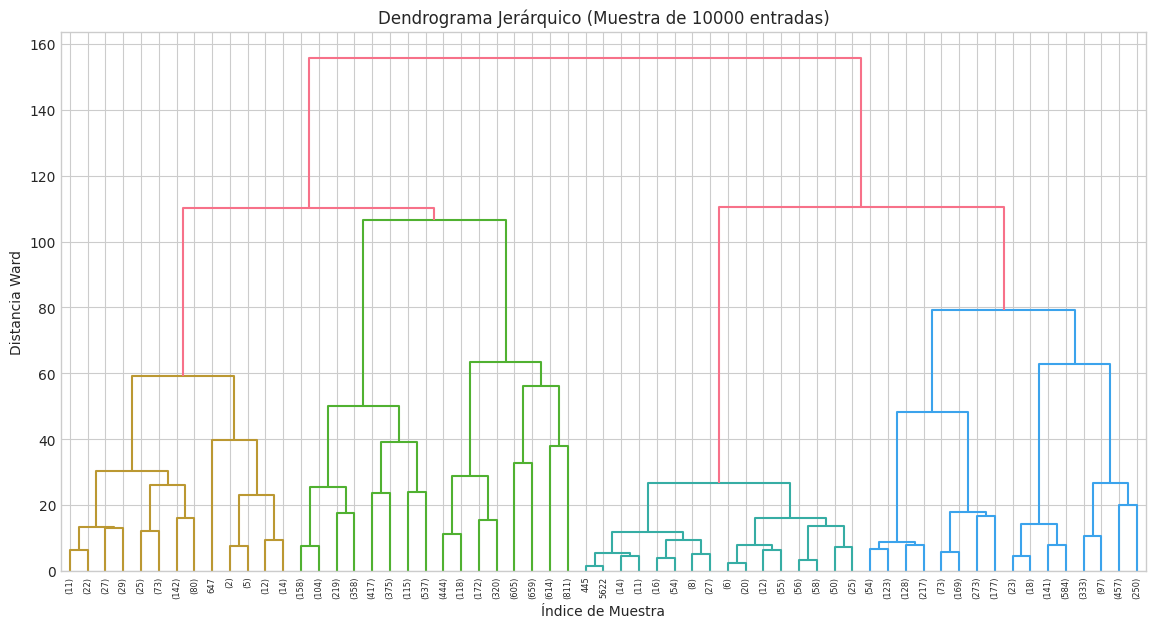

Calculando método del codo...
✓ Gráfico guardado: ../reports/eda_cluvi/elbow_method.png


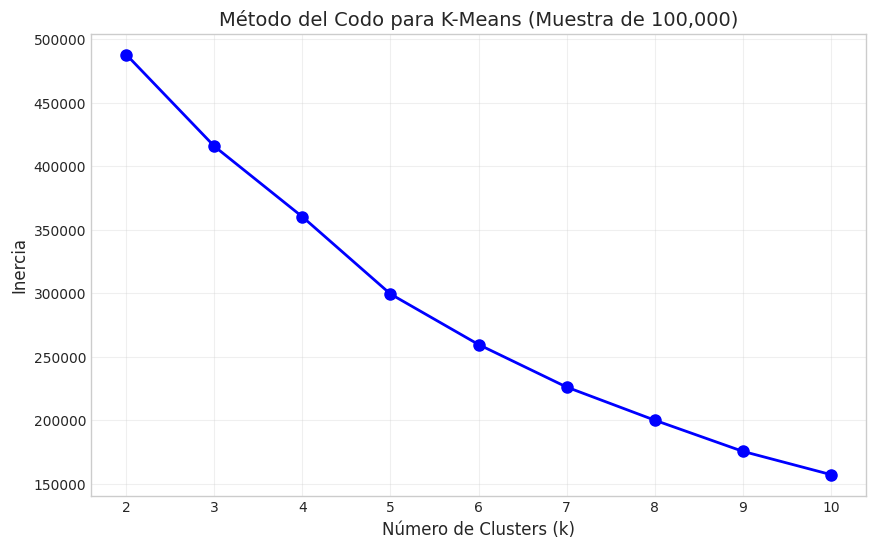

El valor óptimo de k determinado por el método del codo es: 5

Aplicando Mini-Batch K-Means con k=5...

Distribución de categorías por cluster (Top 25 por cluster):

Cluster 0:
category
no especificado      19264
cervezas             11612
whisky                8947
ron                   7840
cócteles              7802
tequila               7784
licores               7344
vinos                 5581
vodka                 4902
vinos tintos          4899
cocteles              4576
vino tinto            3218
vinos blancos         2821
whiskys               2769
ginebra               2763
cocktails             2588
bebidas               2473
cócteles clásicos     2438
gin                   2077
ginebras              1989
vino blanco           1752
cerveza               1642
whiskey               1475
aguardiente           1401
tequilas              1294
Name: count, dtype: int64

Cluster 1:
category
no especificado        23482
bebidas                 5026
entradas                4884
pizza

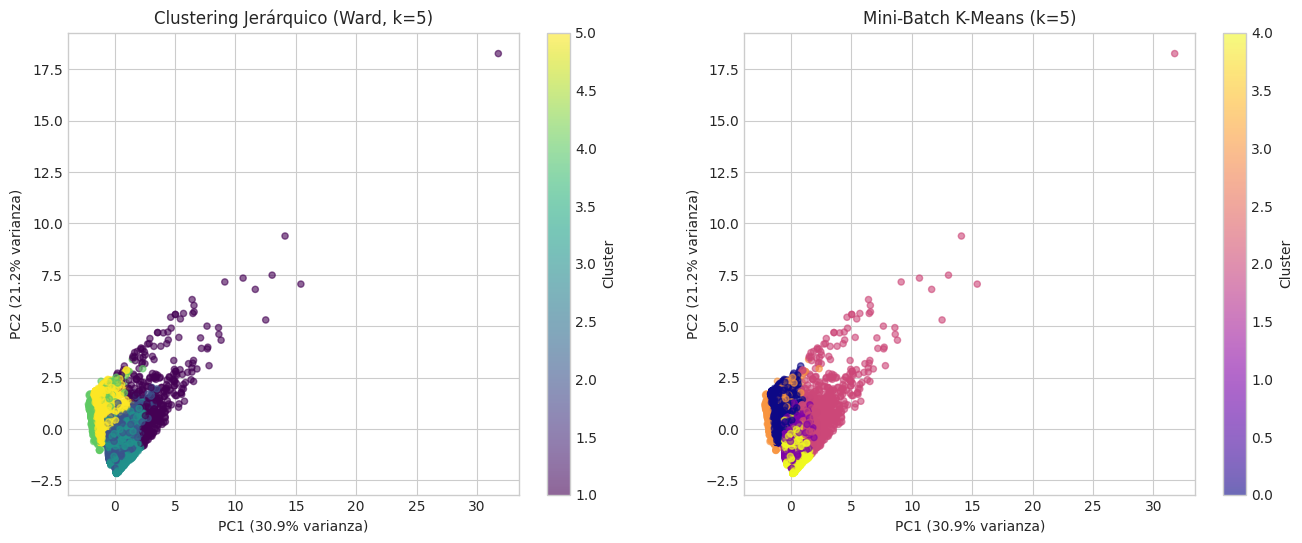

✓ Reporte guardado: ../reports/eda_cluvi/clustering_report.json


In [12]:
# =============================================================================
# SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN
# =============================================================================
print_section("SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN")
liberar_ram()

clustering_report = {}

# Importar KneeLocator para encontrar el codo
from kneed import KneeLocator

# Preparación de datos para clustering (incluyendo nuevas columnas)
print("Preparando datos para clustering...")
df_cluster_full = df.select([
    "description_length_chars", "num_words_description", "category", "is_alcoholic", "type_product", "country_code"
]).to_pandas()

# Encode categóricas
le_cat = LabelEncoder().fit(df_cluster_full["category"])
df_cluster_full["category_encoded"] = le_cat.transform(df_cluster_full["category"])

le_type = LabelEncoder().fit(df_cluster_full["type_product"])
df_cluster_full["type_product_encoded"] = le_type.transform(df_cluster_full["type_product"])

le_country = LabelEncoder().fit(df_cluster_full["country_code"])
df_cluster_full["country_code_encoded"] = le_country.transform(df_cluster_full["country_code"])

# Asumiendo is_alcoholic es booleano, convertir a int
df_cluster_full["is_alcoholic"] = df_cluster_full["is_alcoholic"].astype(int)

features_full = df_cluster_full[["description_length_chars", "num_words_description", "category_encoded", "is_alcoholic", "type_product_encoded", "country_code_encoded"]].values
scaler = StandardScaler()
features_scaled_full = scaler.fit_transform(features_full)

# Muestreo estratificado para dendrograma
sample_size = 10000
df_sample = df.sample(n=min(sample_size, len(df)), seed=42).to_pandas()
df_sample["category_encoded"] = le_cat.transform(df_sample["category"])
df_sample["type_product_encoded"] = le_type.transform(df_sample["type_product"])
df_sample["country_code_encoded"] = le_country.transform(df_sample["country_code"])
df_sample["is_alcoholic"] = df_sample["is_alcoholic"].astype(int)
features_sample = df_sample[["description_length_chars", "num_words_description", "category_encoded", "is_alcoholic", "type_product_encoded", "country_code_encoded"]].values
features_scaled_sample = scaler.transform(features_sample)

# Dendrograma jerárquico
print("Generando dendrograma...")
Z = linkage(features_scaled_sample, method='ward')
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90, ax=ax)
ax.set_title(f"Dendrograma Jerárquico (Muestra de {len(df_sample)} entradas)")
ax.set_xlabel("Índice de Muestra")
ax.set_ylabel("Distancia Ward")
plot_and_save(fig, 'dendrogram.png')

# Método del codo
print("Calculando método del codo...")
elbow_sample_size = min(100000, len(features_scaled_full))
elbow_indices = np.random.choice(len(features_scaled_full), elbow_sample_size, replace=False)
features_elbow = features_scaled_full[elbow_indices]

inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_elbow)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Número de Clusters (k)', fontsize=12)
ax.set_ylabel('Inercia', fontsize=12)
ax.set_title(f'Método del Codo para K-Means (Muestra de {elbow_sample_size:,})', fontsize=14)
ax.grid(True, alpha=0.3)
plot_and_save(fig, 'elbow_method.png')

# K-Means óptimo: Determinar k automáticamente usando KneeLocator
kl = KneeLocator(K_range, inertias, S=1.0, curve="convex", direction="decreasing")
k_opt = int(kl.elbow if kl.elbow else K_range[0]) # Fallback to the smallest k if no clear elbow found
print(f"El valor óptimo de k determinado por el método del codo es: {k_opt}")

print(f"\nAplicando Mini-Batch K-Means con k={k_opt}...")
mb_kmeans = MiniBatchKMeans(n_clusters=k_opt, random_state=42, batch_size=1024, n_init=3)
mb_kmeans.fit(features_scaled_full)
df_cluster_full['cluster'] = mb_kmeans.labels_

# Análisis de clusters
print("\nDistribución de categorías por cluster (Top 25 por cluster):")
for cluster in sorted(df_cluster_full['cluster'].unique()):
    top_cats = df_cluster_full[df_cluster_full['cluster'] == cluster]['category'].value_counts().head(25)
    print(f"\nCluster {cluster}:")
    print(top_cats)

# Guardar la distribución completa si es necesario
cluster_summary_full = df_cluster_full.groupby(['cluster', 'category']).size().unstack(fill_value=0)
save_report(cluster_summary_full, 'cluster_category_full.csv', 'csv')

cluster_means = df_cluster_full.groupby('cluster').agg({
    'description_length_chars': ['mean', 'std', 'min', 'max'],
    'category': 'count'
})
print("\nEstadísticas por cluster:")
print(cluster_means)

# Análisis de clusters con nuevas columnas
cluster_alcoholic = df_cluster_full.groupby('cluster')['is_alcoholic'].mean()
print("\nPorcentaje alcohólico por cluster:")
print(cluster_alcoholic)

print("\nDistribución de type_product por cluster (Top 25 por cluster):")
for cluster in sorted(df_cluster_full['cluster'].unique()):
    top_types = df_cluster_full[df_cluster_full['cluster'] == cluster]['type_product'].value_counts().head(25)
    print(f"\nCluster {cluster}:")
    print(top_types)

# Guardar completa
cluster_type_dist_full = df_cluster_full.groupby(['cluster', 'type_product']).size().unstack(fill_value=0)
save_report(cluster_type_dist_full, 'cluster_type_product_full.csv', 'csv')

print("\nDistribución de country_code por cluster (Top 25 por cluster):")
for cluster in sorted(df_cluster_full['cluster'].unique()):
    top_countries = df_cluster_full[df_cluster_full['cluster'] == cluster]['country_code'].value_counts().head(25)
    print(f"\nCluster {cluster}:")
    print(top_countries)

# Guardar completa
cluster_country_dist_full = df_cluster_full.groupby(['cluster', 'country_code']).size().unstack(fill_value=0)
save_report(cluster_country_dist_full, 'cluster_country_code_full.csv', 'csv')

# Ensure k_opt is a standard Python int for JSON serialization
clustering_report['optimal_k'] = k_opt
clustering_report['inertias'] = {int(k): float(inertia) for k, inertia in zip(K_range, inertias)}

# PCA para visualización
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters jerárquicos
# Usar el k_opt determinado para la visualización jerárquica también, si es apropiado
# O mantener un valor fijo si la visualización jerárquica tiene un propósito diferente
num_clusters_hier = k_opt # Usar k_opt para consistencia, o ajustar si se prefiere un valor fijo para el dendrograma
clusters_hier = fcluster(Z, t=num_clusters_hier, criterion='maxclust')
scatter1 = axes[0].scatter(features_pca[:, 0], features_pca[:, 1], 
                           c=clusters_hier, cmap='viridis', alpha=0.6, s=20)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
axes[0].set_title(f'Clustering Jerárquico (Ward, k={num_clusters_hier})')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: K-Means en muestra
df_sample['cluster_kmeans'] = mb_kmeans.predict(features_scaled_sample)
scatter2 = axes[1].scatter(features_pca[:, 0], features_pca[:, 1], 
                           c=df_sample['cluster_kmeans'], cmap='plasma', alpha=0.6, s=20)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
axes[1].set_title(f'Mini-Batch K-Means (k={k_opt})')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plot_and_save(fig, 'clustering_pca.png')

save_report(clustering_report, 'clustering_report.json')


SECCIÓN 8: ANÁLISIS DE CORRELACIONES
RAM liberada: 0.00 MB
RAM actual: 2265.19 MB
✓ Gráfico guardado: ../reports/eda_cluvi/correlation_matrix.png


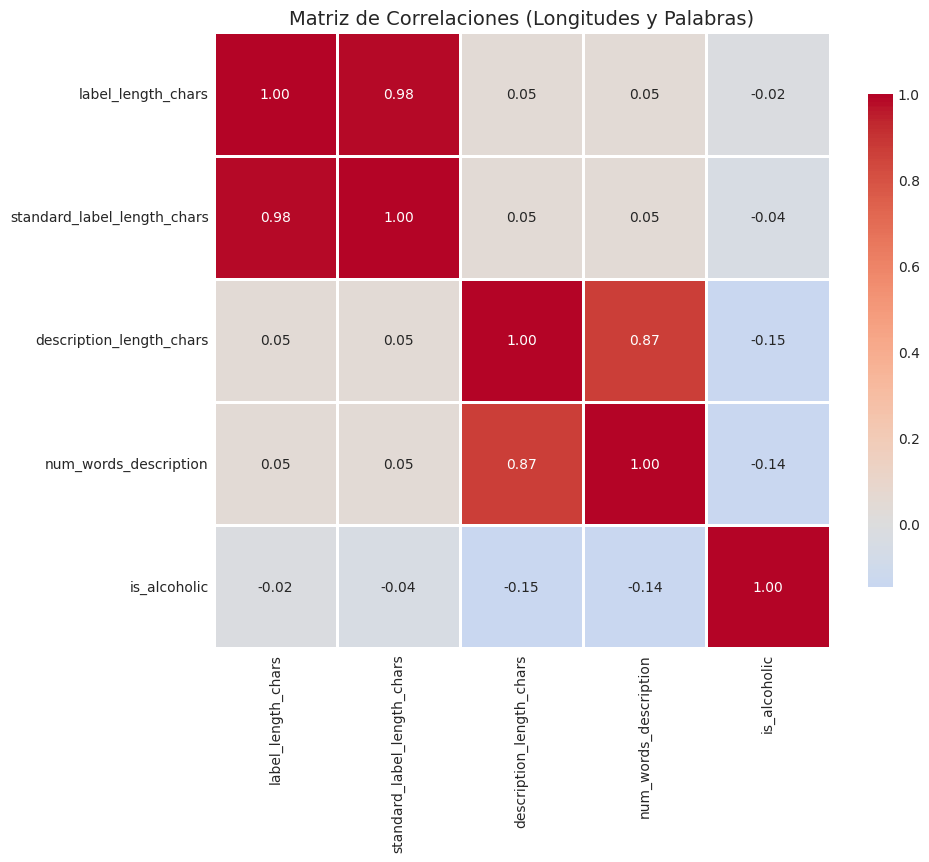


Correlaciones más fuertes (|r| > 0.5, excluyendo diagonales):
  label_length_chars <-> standard_label_length_chars: 0.983
  description_length_chars <-> num_words_description: 0.871


In [13]:
# =============================================================================
# SECCIÓN 8: ANÁLISIS DE CORRELACIONES
# =============================================================================
print_section("SECCIÓN 8: ANÁLISIS DE CORRELACIONES")
liberar_ram()

# Correlaciones numéricas (incluyendo is_alcoholic como numérica)
corr_cols = ["label_length_chars", "standard_label_length_chars", "description_length_chars", "num_words_description", "is_alcoholic"]
corr_df = df.select(corr_cols).to_pandas().corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de Correlaciones (Longitudes y Palabras)", fontsize=14)
plot_and_save(fig, 'correlation_matrix.png')

# Correlaciones destacables
print("\nCorrelaciones más fuertes (|r| > 0.5, excluyendo diagonales):")
corr_pairs = []
for i in range(len(corr_df.columns)):
    for j in range(i+1, len(corr_df.columns)):
        corr_val = corr_df.iloc[i, j]
        if abs(corr_val) > 0.5:
            corr_pairs.append({
                'var1': corr_df.columns[i],
                'var2': corr_df.columns[j],
                'correlation': corr_val
            })

for pair in sorted(corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
    print(f"  {pair['var1']} <-> {pair['var2']}: {pair['correlation']:.3f}")

In [14]:
# =============================================================================
# SECCIÓN 9: ANÁLISIS DE LABELS ESPECÍFICAS
# =============================================================================
print_section("SECCIÓN 9: ANÁLISIS DE LABELS ESPECÍFICAS")

label_analysis = {}

# Top labels más frecuentes (si hay duplicados)
print("\n--- Top 20 Labels Más Frecuentes ---")
label_freq = df.group_by("label").agg([
    pl.count().alias("frequency"),
    pl.col("category").first().alias("category")
]).sort("frequency", descending=True)

print(label_freq.head(20))

# Labels que aparecen con un solo categoría vs múltiples
label_cat_variety = df.group_by("label").agg([
    pl.col("category").n_unique().alias("num_categories"),
    pl.count().alias("total_occurrences")
])

single_cat = label_cat_variety.filter(pl.col("num_categories") == 1)
multi_cat = label_cat_variety.filter(pl.col("num_categories") > 1)

print(f"\nLabels con categoría única: {len(single_cat)} ({100*len(single_cat)/len(label_cat_variety):.1f}%)")
print(f"Labels con múltiples categorías: {len(multi_cat)} ({100*len(multi_cat)/len(label_cat_variety):.1f}%)")

label_analysis['single_cat_labels'] = len(single_cat)
label_analysis['multi_cat_labels'] = len(multi_cat)

# Análisis de capitalización por categoría
caps_by_cat = df.group_by("category").agg([
    pl.col("label_all_caps").mean().alias("pct_label_all_caps"),
    pl.col("has_numbers").mean().alias("pct_with_numbers")
]).sort("pct_label_all_caps", descending=True)

print("\nCaracterísticas textuales por categoría (top 10):")
print(caps_by_cat.head(10))

# Palabras más comunes en descripciones
print("\n--- Análisis de Palabras en Descripciones ---")
all_words = df["description_lower"].str.split(" ").explode()
word_freq = all_words.value_counts().head(30)
print("Top 30 palabras más frecuentes en descripciones:")
print(word_freq)

# Análisis de labels por columnas nuevas
print("\n--- Top Labels por Type_Product ---")
label_by_type = df.group_by(["type_product", "label"]).agg(
    pl.count().alias("frequency")
).sort(["type_product", "frequency"], descending=[False, True]).group_by("type_product").head(5)
print(label_by_type)

print("\n--- Porcentaje Alcohólico por Country_Code ---")
alc_by_country = df.group_by("country_code").agg(
    pl.col("is_alcoholic").mean().alias("pct_alcoholic")
).sort("pct_alcoholic", descending=True)
print(alc_by_country)

save_report(label_analysis, 'label_analysis.json')


SECCIÓN 9: ANÁLISIS DE LABELS ESPECÍFICAS

--- Top 20 Labels Más Frecuentes ---
shape: (20, 3)
┌───────────────┬───────────┬──────────────────────┐
│ label         ┆ frequency ┆ category             │
│ ---           ┆ ---       ┆ ---                  │
│ str           ┆ u32       ┆ str                  │
╞═══════════════╪═══════════╪══════════════════════╡
│ corona        ┆ 2110      ┆ cervezas corrientes  │
│ stella artois ┆ 1684      ┆ cervezas             │
│ margarita     ┆ 1631      ┆ cócteles / cocktails │
│ mojito        ┆ 1447      ┆ cocktails            │
│ heineken      ┆ 1333      ┆ cervezas             │
│ …             ┆ …         ┆ …                    │
│ grey goose    ┆ 892       ┆ vodka                │
│ club colombia ┆ 891       ┆ cervezas             │
│ fondo         ┆ 891       ┆ fondo mentiroso      │
│ capuccino     ┆ 863       ┆ pizzas               │
│ budweiser     ┆ 811       ┆ cervezas             │
└───────────────┴───────────┴──────────────────────┘



Labels con categoría única: 228052 (80.0%)
Labels con múltiples categorías: 57117 (20.0%)

Características textuales por categoría (top 10):
shape: (10, 3)
┌─────────────────────────────┬────────────────────┬──────────────────┐
│ category                    ┆ pct_label_all_caps ┆ pct_with_numbers │
│ ---                         ┆ ---                ┆ ---              │
│ str                         ┆ f64                ┆ f64              │
╞═════════════════════════════╪════════════════════╪══════════════════╡
│ pruebas                     ┆ 1.0                ┆ 0.0              │
│ adiciones¡                  ┆ 1.0                ┆ 0.0              │
│ información de alérgenos    ┆ 1.0                ┆ 0.0              │
│                             ┆ 1.0                ┆ 0.0              │
│ información sobre alérgenos ┆ 1.0                ┆ 0.0              │
│ adiciones-                  ┆ 1.0                ┆ 0.0              │
│ información alergenos       ┆ 1.0                

In [15]:
# =============================================================================
# SECCIÓN 10: CASOS EXTREMOS Y MUESTRAS PARA REVISIÓN MANUAL
# =============================================================================
print_section("SECCIÓN 10: CASOS EXTREMOS PARA REVISIÓN MANUAL")

extreme_cases = {}

# 1. Descripciones más largas
print("\n--- Top 15 Descripciones Más Largas ---")
longest_desc = df.sort("description_length_chars", descending=True).head(15).select([
    "label", "description", "category", "description_length_chars"
])
print(longest_desc)
save_report(longest_desc.to_pandas(), 'longest_descriptions.csv', 'csv')

# 2. Descripciones más cortas (posibles errores)
print("\n--- Descripciones Más Cortas (≤5 chars) ---")
shortest_desc = df.filter(pl.col("description_length_chars") <= 5).head(20).select([
    "label", "description", "category"
])
print(shortest_desc)
extreme_cases['short_desc_entities'] = len(df.filter(pl.col("description_length_chars") <= 5))

# 3. Categorías con más entradas
print("\n--- Top 10 Categorías Con Más Entradas ---")
most_entries = df.group_by("category").agg(pl.count().alias("num_entries")).sort("num_entries", descending=True).head(10)
print(most_entries)

# Obtener muestras de estas categorías para inspección
if len(most_entries) > 0:
    top_cat_names = most_entries["category"].to_list()
    top_samples = df.filter(pl.col("category").is_in(top_cat_names)).group_by("category").head(1).select([
        "label", "description", "category"
    ])
    
    print("\nMuestra de 5 categorías con más entradas:")
    print(top_samples.head(5))

# 4. Labels con caracteres especiales inusuales
print("\n--- Labels con Caracteres Especiales ---")
special_char_labels = df.filter(
    pl.col("label").str.contains(r"[^\w\s\-']")  # No alfanumérico, espacio, guión o apóstrofo
).head(20).select(["label", "category"])
print(special_char_labels)
extreme_cases['labels_with_special_chars'] = len(df.filter(
    pl.col("label").str.contains(r"[^\w\s\-']")
))

# 5. Labels numéricas puras
print("\n--- Labels Numéricas Puras ---")
numeric_labels = df.filter(
    pl.col("label").str.contains(r"^\d+$")
).head(20).select(["label", "category"])
print(numeric_labels)
extreme_cases['pure_numeric_labels'] = len(df.filter(
    pl.col("label").str.contains(r"^\d+$")
))

# 6. Casos extremos para nuevas columnas
print("\n--- Top Type_Product con Más Alcohólicos ---")
extreme_alc_type = df.filter(pl.col("is_alcoholic") == True).group_by("type_product").agg(
    pl.count().alias("num_alcoholic")
).sort("num_alcoholic", descending=True).head(10)
print(extreme_alc_type)

print("\n--- Country_Code con Mayor Porcentaje Alcohólico ---")
extreme_alc_country = alc_by_country.head(10)
print(extreme_alc_country)

extreme_cases['most_alcoholic_types'] = len(extreme_alc_type)

save_report(extreme_cases, 'extreme_cases.json')


SECCIÓN 10: CASOS EXTREMOS PARA REVISIÓN MANUAL

--- Top 15 Descripciones Más Largas ---
shape: (15, 4)
┌──────────────────────────┬─────────────────────────┬───────────────────┬─────────────────────────┐
│ label                    ┆ description             ┆ category          ┆ description_length_char │
│ ---                      ┆ ---                     ┆ ---               ┆ s                       │
│ str                      ┆ str                     ┆ str               ┆ ---                     │
│                          ┆                         ┆                   ┆ u32                     │
╞══════════════════════════╪═════════════════════════╪═══════════════════╪═════════════════════════╡
│ croquetas de  salmón     ┆ <img src="data:image/pn ┆ entradas          ┆ 7997                    │
│ (salmon c…               ┆ g;base6…                ┆                   ┆                         │
│ budweiser 250ml          ┆ <img src="data:image/pn ┆ bebidas - cerveza ┆ 7997        

✓ Reporte guardado: ../reports/eda_cluvi/longest_descriptions.csv

--- Descripciones Más Cortas (≤5 chars) ---
shape: (20, 3)
┌────────────────────────┬─────────────┬────────────────────┐
│ label                  ┆ description ┆ category           │
│ ---                    ┆ ---         ┆ ---                │
│ str                    ┆ str         ┆ str                │
╞════════════════════════╪═════════════╪════════════════════╡
│ ramón bilbao botella   ┆             ┆ bebidas            │
│ agua manantial 600ml   ┆             ┆ gaseosas           │
│ aguardiente antioqueño ┆             ┆ guaro la tiendita  │
│ capuccino              ┆             ┆ pizzas             │
│ cogollo tudela         ┆             ┆ de la huerta       │
│ …                      ┆ …           ┆ …                  │
│ becks                  ┆             ┆ cervezas           │
│ ensalada epoca         ┆             ┆ ensaladas / salads │
│ con camarón especial   ┆             ┆ los clamatos       │
│ soda


SECCIÓN 11: RESUMEN EJECUTIVO



RESUMEN EJECUTIVO
{
  "dataset_overview": {
    "total_entries": 736181,
    "unique_labels": 285169,
    "unique_categories": 20843,
    "unique_type_product": 5,
    "unique_country_code": 11,
    "num_main_categories": 7272,
    "coverage_top_main_cat": [
      {
        "main_category": "no especificado",
        "count": 218154,
        "coverage_pct": 29.63320161753699
      },
      {
        "main_category": "bebidas",
        "count": 70486,
        "coverage_pct": 9.574547563710555
      },
      {
        "main_category": "licores",
        "count": 38230,
        "coverage_pct": 5.19301639134941
      },
      {
        "main_category": "vinos",
        "count": 19473,
        "coverage_pct": 2.6451375409036633
      },
      {
        "main_category": "entradas",
        "count": 12981,
        "coverage_pct": 1.7632891911092514
      }
    ]
  },
  "quality_metrics": {
    "null_counts": {
      "label": 0,
      "standard_label": 0,
      "description": 0,
      "catego

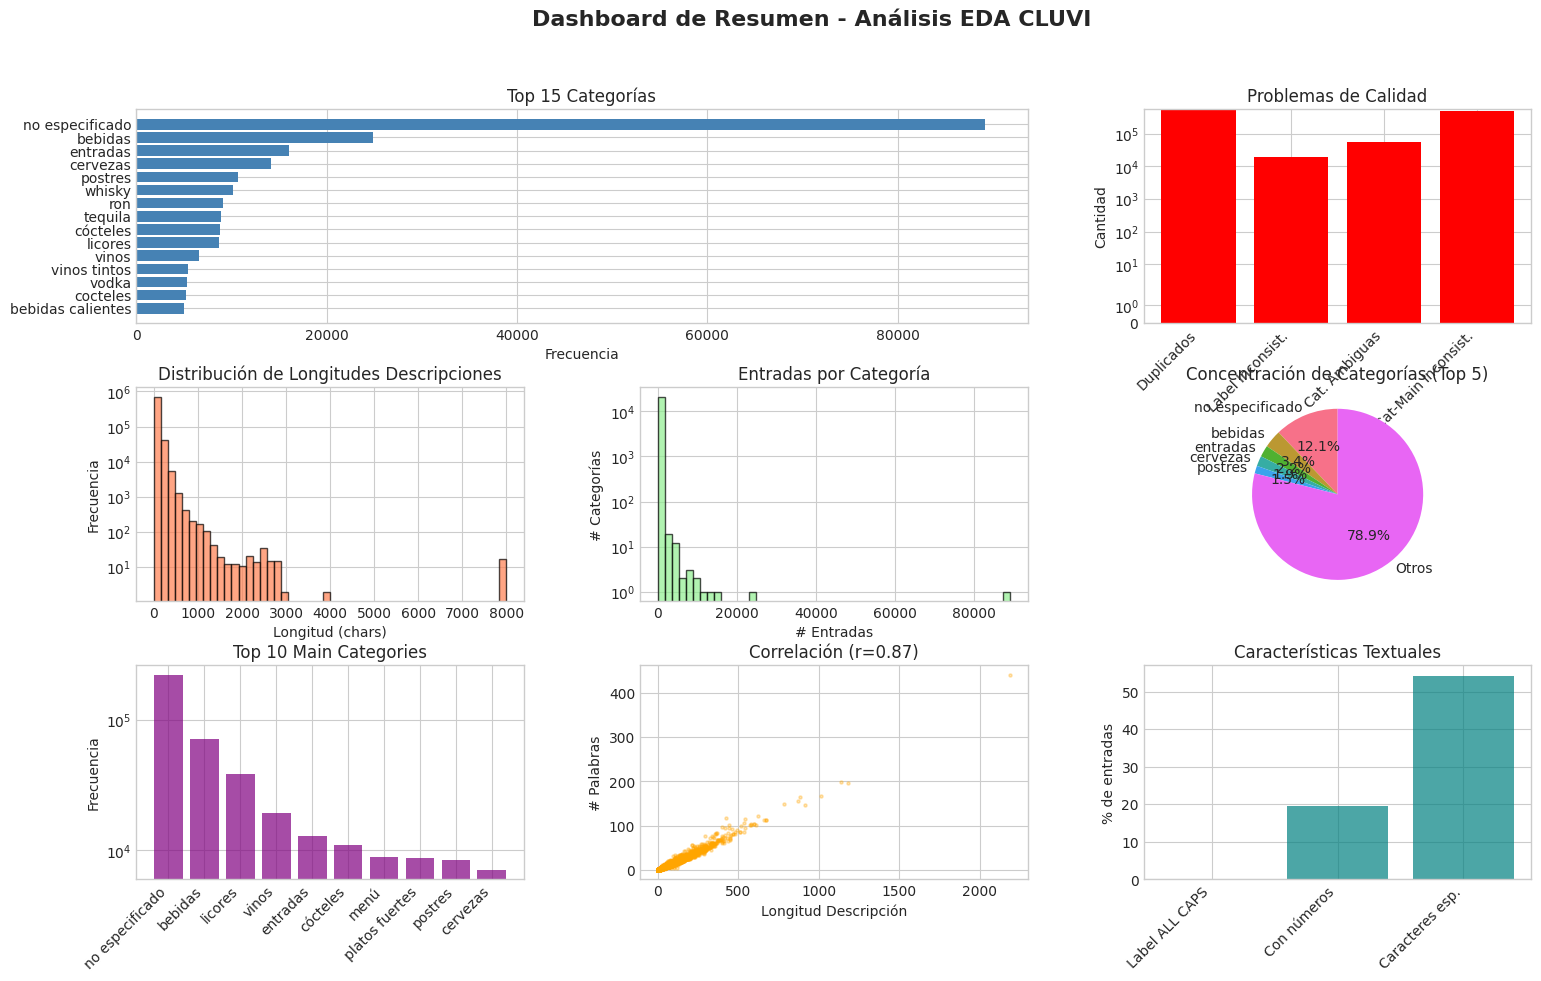

In [16]:
# =============================================================================
# SECCIÓN 11: RESUMEN EJECUTIVO Y EXPORTACIÓN FINAL
# =============================================================================
print_section("SECCIÓN 11: RESUMEN EJECUTIVO")

executive_summary = {
    "dataset_overview": {
        "total_entries": total_entries,
        "unique_labels": unique_labels,
        "unique_categories": unique_categories,
        "unique_type_product": unique_type_product,
        "unique_country_code": unique_country_code,
        "num_main_categories": len(main_cat_dist),
        "coverage_top_main_cat": basic_stats.get('coverage_top_main_cat', []),
    },
    "quality_metrics": quality_report,
    "imbalance_metrics": {
        "gini_coefficient": float(gini),
        "entropy": float(ent),
        "max_min_ratio": float(max_ratio)
    },
    "top_5_categories": cat_dist.head(5).to_pandas().to_dict('records'),
    "length_statistics": {
        "mean_desc_length": float(df["description_length_chars"].mean()),
        "median_desc_length": float(df["description_length_chars"].median()),
        "max_desc_length": int(df["description_length_chars"].max()),
        "mean_label_length": float(df["label_length_chars"].mean())
    },
    "category_validation": category_report,
    "clustering": {
        "optimal_clusters": k_opt,
        "pca_variance_explained": float(pca.explained_variance_ratio_.sum())
    },
    "extreme_cases": extreme_cases,
    "recommendations": [
        "Revisar labels duplicados" if quality_report.get('duplicates', 0) > 0 else "✓ No hay duplicados",
        "Resolver inconsistencias label vs standard_label" if quality_report.get('label_inconsistencies', 0) > 0 else "✓ Labels consistentes",
        "Resolver labels ambiguos con múltiples categorías" if quality_report.get('ambiguous_categories', 0) > 0 else "✓ No hay ambigüedades",
        "Validar diferencias category vs main_category" if category_report.get('category_inconsistencies', 0) > 0 else "✓ Categorías consistentes",
        f"Considerar estratificación por categoría (Gini={gini:.2f})" if gini > 0.6 else "✓ Balance aceptable de categorías",
        "Revisar descripciones de ≤5 chars" if extreme_cases.get('short_desc_entities', 0) > 100 else "✓ Pocas descripciones cortas",
        "Analizar distribución de type_product y country_code para sesgos geográficos o de tipo"
    ]
}

print("\n" + "="*80)
print("RESUMEN EJECUTIVO")
print("="*80)
print(json.dumps(executive_summary, indent=2, ensure_ascii=False))

save_report(executive_summary, 'executive_summary.json')

# Gráfico de resumen final
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Distribución de categorías (barras horizontales, top 15)
ax1 = fig.add_subplot(gs[0, :2])
top15_dist = cat_dist.head(15).to_pandas()

# Eliminar filas donde category es None o NaN para evitar errores en el gráfico
top15_dist = top15_dist[top15_dist["category"].notnull()]

# Convertir category a string explícitamente (por si acaso)
top15_dist["category"] = top15_dist["category"].astype(str)

ax1.barh(top15_dist["category"], top15_dist["count"], color='steelblue')
ax1.set_xlabel("Frecuencia")
ax1.set_title("Top 15 Categorías")
ax1.invert_yaxis()

# 2. Métricas de calidad
ax2 = fig.add_subplot(gs[0, 2])
quality_metrics = [
    quality_report.get('duplicates', 0),
    quality_report.get('label_inconsistencies', 0),
    quality_report.get('ambiguous_categories', 0),
    category_report.get('category_inconsistencies', 0)
]
quality_labels = ['Duplicados', 'Label Inconsist.', 'Cat. Ambiguas', 'Cat-Main Inconsist.']
colors_quality = ['red' if m > 0 else 'green' for m in quality_metrics]
ax2.bar(range(len(quality_metrics)), quality_metrics, color=colors_quality)
ax2.set_xticks(range(len(quality_labels)))
ax2.set_xticklabels(quality_labels, rotation=45, ha='right')
ax2.set_ylabel("Cantidad")
ax2.set_title("Problemas de Calidad")
ax2.set_yscale('symlog')

# 3. Distribución de longitudes de descripciones
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(df["description_length_chars"].to_numpy(), bins=50, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel("Longitud (chars)")
ax3.set_ylabel("Frecuencia")
ax3.set_title("Distribución de Longitudes Descripciones")
ax3.set_yscale('log')

# 4. Entradas por categoría
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(df.group_by("category").agg(pl.count())["count"].to_numpy(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax4.set_xlabel("# Entradas")
ax4.set_ylabel("# Categorías")
ax4.set_title("Entradas por Categoría")
ax4.set_yscale('log')

# 5. Desbalance (pie chart)
ax5 = fig.add_subplot(gs[1, 2])
top5_counts = cat_dist.head(5)["count"].to_numpy()
others = cat_dist["count"].sum() - top5_counts.sum()
pie_data = list(top5_counts) + [others]
pie_labels = cat_dist.head(5)["category"].to_list() + ['Otros']
ax5.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax5.set_title("Concentración de Categorías (Top 5)")

# 6. Distribución de main_categories
ax6 = fig.add_subplot(gs[2, 0])
main_top = main_cat_dist.head(10).to_pandas()
ax6.bar(range(len(main_top)), main_top["count"], color='purple', alpha=0.7)
ax6.set_xticks(range(len(main_top)))
ax6.set_xticklabels(main_top["main_category"], rotation=45, ha='right')
ax6.set_ylabel("Frecuencia")
ax6.set_title("Top 10 Main Categories")
ax6.set_yscale('log')

# 7. Correlación longitud-palabras
ax7 = fig.add_subplot(gs[2, 1])
scatter_sample = df.sample(n=min(10000, len(df)), seed=42).to_pandas()
ax7.scatter(scatter_sample["description_length_chars"], scatter_sample["num_words_description"], 
            alpha=0.3, s=5, color='orange')
ax7.set_xlabel("Longitud Descripción")
ax7.set_ylabel("# Palabras")
ax7.set_title(f"Correlación (r={corr_length_words:.2f})")

# 8. Características textuales
ax8 = fig.add_subplot(gs[2, 2])
char_features_pct = [
    100 * caps_stats["label_all_caps"][0] / total_entries,
    100 * caps_stats["with_numbers"][0] / total_entries,
    100 * caps_stats["with_special_chars"][0] / total_entries,
]
char_labels = ['Label ALL CAPS', 'Con números', 'Caracteres esp.']
ax8.bar(range(len(char_features_pct)), char_features_pct, color='teal', alpha=0.7)
ax8.set_xticks(range(len(char_labels)))
ax8.set_xticklabels(char_labels, rotation=45, ha='right')
ax8.set_ylabel("% de entradas")
ax8.set_title("Características Textuales")

fig.suptitle("Dashboard de Resumen - Análisis EDA CLUVI", fontsize=16, fontweight='bold')
plot_and_save(fig, 'executive_dashboard.png')

In [17]:
# =============================================================================
# FINALIZACIÓN
# =============================================================================
print("\n" + "="*80)
print("✓ EDA COMPLETADO EXITOSAMENTE")
print("="*80)
print(f"\nReportes generados en: {REPORT_DIR}")
print("\nArchivos creados:")
for report_file in sorted(REPORT_DIR.glob("*")):
    print(f"  - {report_file.name}")

print("\n" + "="*80)
print("RECOMENDACIONES FINALES:")
print("="*80)
for i, rec in enumerate(executive_summary['recommendations'], 1):
    print(f"{i}. {rec}")

print("\n¡Análisis completado! Revisa los reportes y visualizaciones generadas.")
print("="*80)


✓ EDA COMPLETADO EXITOSAMENTE

Reportes generados en: ../reports/eda_cluvi

Archivos creados:
  - Graficas.pdf
  - ambiguous_categories.csv
  - basic_stats.json
  - category_distribution.png
  - category_stats.json
  - category_validation_report.json
  - cluster_category_full.csv
  - cluster_country_code_full.csv
  - cluster_type_product_full.csv
  - clustering_pca.png
  - clustering_report.json
  - cooccurrence_report.json
  - cooccurrences.csv
  - correlation_matrix.png
  - dendrogram.png
  - elbow_method.png
  - executive_dashboard.png
  - executive_summary.json
  - extreme_cases.json
  - json_to_txt.py
  - label_analysis.json
  - longest_descriptions.csv
  - post_preprocess_stats.json
  - preprocess_report.json
  - quality_report.json
  - text_analysis.json
  - text_analysis.png
  - txts

RECOMENDACIONES FINALES:
1. Revisar labels duplicados
2. Resolver inconsistencias label vs standard_label
3. Resolver labels ambiguos con múltiples categorías
4. Validar diferencias category vs m

In [18]:
# =============================================================================
# PREPROCESADO AJUSTADO (NORMALIZACIÓN AL INICIO)
# =============================================================================
print_section("PREPROCESADO AJUSTADO BASADO EN FEEDBACK")

preprocess_report = {}

# Validación inicial: Verificar columnas esperadas y nulos
expected_columns = ["label", "standard_label", "description", "category", "main_category", "is_alcoholic", "type_product", "country_code"]
missing_cols = [col for col in expected_columns if col not in df_full.columns]
if missing_cols:
    raise ValueError(f"Columnas faltantes en df_full: {missing_cols}")
print("✓ Columnas verificadas:", df_full.columns)

# Verificar nulos (aunque EDA reportó 0, para robustez)
null_counts = df_full.null_count()
if any(null_counts[col][0] > 0 for col in expected_columns):
    print("⚠️ Nulos detectados:", {col: int(null_counts[col][0]) for col in null_counts.columns})
    df_clean = df_full.drop_nulls(subset=["label", "category", "main_category"])
else:
    df_clean = df_full.clone()
print(f"Shape inicial: {df_clean.shape}")


PREPROCESADO AJUSTADO BASADO EN FEEDBACK
✓ Columnas verificadas: ['label', 'standard_label', 'description', 'category', 'main_category', 'is_alcoholic', 'type_product', 'country_code']
Shape inicial: (736181, 8)


In [19]:
# Paso 1: Normalización de texto y resolución label -> standard_label (feedback: sí, normalizar al inicio)
print("\n--- Paso 1: Normalización de Texto y Resolución de Label ---")
df_clean = df_clean.with_columns([
    # Label: Convertir a minúsculas, reemplazar saltos de línea/tabulaciones por espacio,
    # eliminar caracteres no alfanuméricos (incluyendo emojis), normalizar espacios múltiples a uno, y limpiar extremos.
    pl.col("standard_label")
      .str.to_lowercase()
      .str.replace_all(r"[\n\t\r]", " ")
      .str.replace_all(r"[^\w\s]", "") # Elimina caracteres no alfanuméricos, incluyendo emojis
      .str.replace_all(r"\s+", " ")
      .str.strip_chars()
      .alias("label"),

    # Description: Convertir a minúsculas, reemplazar saltos de línea/tabulaciones por espacio,
    # eliminar caracteres no permitidos (excepto espacios y puntuación específica, incluyendo emojis), normalizar espacios múltiples a uno, y limpiar extremos.
    pl.col("description")
      .str.to_lowercase()
      .str.replace_all(r"[\n\t\r]", " ")
      .str.replace_all(r"[^\w\s.,/-]", "") # Elimina caracteres no permitidos, incluyendo emojis
      .str.replace_all(r"\s+", " ")
      .str.strip_chars()
      .alias("description"),

    # Category: Convertir a minúsculas, reemplazar saltos de línea/tabulaciones por espacio,
    # eliminar caracteres no alfanuméricos (incluyendo emojis), normalizar espacios múltiples a uno, y limpiar extremos.
    pl.col("category")
      .str.to_lowercase()
      .str.replace_all(r"[\n\t\r]", " ")
      .str.replace_all(r"[^\w\s]", "") # Elimina caracteres no alfanuméricos, incluyendo emojis
      .str.replace_all(r"\s+", " ")
      .str.strip_chars()
      .alias("category"),

    # Main Category: Convertir a minúsculas, reemplazar saltos de línea/tabulaciones por espacio,
    # eliminar caracteres no alfanuméricos (incluyendo emojis), normalizar espacios múltiples a uno, y limpiar extremos.
    pl.col("main_category")
      .str.to_lowercase()
      .str.replace_all(r"[\n\t\r]", " ")
      .str.replace_all(r"[^\w\s]", "") # Elimina caracteres no alfanuméricos, incluyendo emojis
      .str.replace_all(r"\s+", " ")
      .str.strip_chars()
      .alias("main_category"),

    # Type Product: Convertir a minúsculas, reemplazar saltos de línea/tabulaciones por espacio,
    # eliminar caracteres no alfanuméricos (incluyendo emojis), normalizar espacios múltiples a uno, y limpiar extremos.
    pl.col("type_product")
      .str.to_lowercase()
      .str.replace_all(r"[\n\t\r]", " ")
      .str.replace_all(r"[^\w\s]", "") # Elimina caracteres no alfanuméricos, incluyendo emojis
      .str.replace_all(r"\s+", " ")
      .str.strip_chars()
      .alias("type_product"),

    # Country Code: Convertir a mayúsculas, reemplazar saltos de línea/tabulaciones por espacio,
    # eliminar caracteres no alfanuméricos (incluyendo emojis), normalizar espacios múltiples a uno, y limpiar extremos.
    pl.col("country_code")
      .str.to_uppercase()
      .str.replace_all(r"[\n\t\r]", " ")
      .str.replace_all(r"[^\w\s]", "") # Elimina caracteres no alfanuméricos, incluyendo emojis
      .str.replace_all(r"\s+", " ")
      .str.strip_chars()
      .alias("country_code")
])
# Filtrar labels numéricos puros (como se identificó en el EDA, para eliminar ruido)
df_clean = df_clean.filter(~pl.col("label").str.contains(r"^\d+$"))
print(f"Shape después de normalización y filtrado numéricos: {df_clean.shape}")
preprocess_report['numeric_labels_removed'] = df_full.height - df_clean.height


--- Paso 1: Normalización de Texto y Resolución de Label ---


Shape después de normalización y filtrado numéricos: (735922, 8)


In [20]:
# Paso 2: Eliminación de duplicados con combinación (feedback: label, description, category, main_category)
print("\n--- Paso 2: Eliminación de Duplicados ---")
df_clean = df_clean.unique(subset=["label", "description", "category", "main_category"], keep="first")
print(f"Shape después de unique: {df_clean.shape}")
preprocess_report['duplicates_removed'] = df_full.height - df_clean.height


--- Paso 2: Eliminación de Duplicados ---


Shape después de unique: (611525, 8)


In [21]:
# Paso 3: Excluir "no especificado" en category y main_category (feedback)
print("\n--- Paso 3: Excluir 'no especificado' ---")
df_clean = df_clean.filter(
    (pl.col("category") != "no especificado") &
    (pl.col("main_category") != "no especificado")
)
print(f"Shape después de excluir 'no especificado': {df_clean.shape}")
preprocess_report['no_especificado_removed'] = df_full.height - df_clean.height


--- Paso 3: Excluir 'no especificado' ---


Shape después de excluir 'no especificado': (444855, 8)


In [22]:
# Paso 4: Agrupar raras en "otros" para category y main_category (feedback: sí)
print("\n--- Paso 4: Agrupar Categorías Raras ---")
rare_threshold = 10  # Ajustable; basado en mean ~32 del EDA

# Para category
cat_counts = df_clean["category"].value_counts()
rare_cats = cat_counts.filter(pl.col("count") < rare_threshold)["category"]
df_clean = df_clean.with_columns(
    pl.when(pl.col("category").is_in(rare_cats))
    .then(pl.lit("otros"))
    .otherwise(pl.col("category"))
    .alias("category")
)
preprocess_report['rare_categories_grouped'] = len(rare_cats)

# Para main_category
main_cat_counts = df_clean["main_category"].value_counts()
rare_main = main_cat_counts.filter(pl.col("count") < rare_threshold)["main_category"]
df_clean = df_clean.with_columns(
    pl.when(pl.col("main_category").is_in(rare_main))
    .then(pl.lit("otros"))
    .otherwise(pl.col("main_category"))
    .alias("main_category")
)
preprocess_report['rare_main_categories_grouped'] = len(rare_main)
print(f"Categorías únicas después: {df_clean['category'].n_unique()} | Main categorías únicas: {df_clean['main_category'].n_unique()}")


--- Paso 4: Agrupar Categorías Raras ---


Categorías únicas después: 5788 | Main categorías únicas: 3627


In [23]:
# Paso 6: Columnas nuevas (feedback: sí)
print("\n--- Paso 6: Tratamiento de Columnas Nuevas ---")
df_clean = df_clean.with_columns(pl.col("is_alcoholic").cast(pl.Int32))
df_clean = df_clean.with_columns(
    pl.when(pl.col("type_product") == "no especificado")
    .then(pl.lit("otros"))
    .otherwise(pl.col("type_product"))
    .alias("type_product")
)


--- Paso 6: Tratamiento de Columnas Nuevas ---


In [24]:
# Paso 7: Agregar features derivadas (longitudes, útil para LLM)
print("\n--- Paso 7: Agregar Features Derivadas ---")
df_clean = df_clean.with_columns([
    pl.col("description").str.len_chars().alias("desc_length"),
    pl.col("description").str.split(" ").list.len().alias("desc_words")
])


--- Paso 7: Agregar Features Derivadas ---


In [25]:
# Paso 8: Agregar clustering como feature (opcional, como se explicó)
print("\n--- Paso 8: Agregar Clusters ---")
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import MiniBatchKMeans
import numpy as np

df_cluster = df_clean.select([
    "desc_length", "desc_words", "category", "is_alcoholic", "type_product", "country_code"
]).to_pandas()

le_cat = LabelEncoder().fit(df_cluster["category"])
df_cluster["category_encoded"] = le_cat.transform(df_cluster["category"])

le_type = LabelEncoder().fit(df_cluster["type_product"])
df_cluster["type_product_encoded"] = le_type.transform(df_cluster["type_product"])

le_country = LabelEncoder().fit(df_cluster["country_code"])
df_cluster["country_code_encoded"] = le_country.transform(df_cluster["country_code"])

df_cluster["is_alcoholic"] = df_cluster["is_alcoholic"].astype(int)

features = df_cluster[["desc_length", "desc_words", "category_encoded", "is_alcoholic", "type_product_encoded", "country_code_encoded"]].values
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

k_opt = 5  # De EDA
mb_kmeans = MiniBatchKMeans(n_clusters=k_opt, random_state=42, batch_size=1024, n_init=3)
mb_kmeans.fit(features_scaled)
df_clean = df_clean.with_columns(pl.Series("cluster", mb_kmeans.labels_).cast(pl.Int32))
print("Clusters agregados (0-4).")


--- Paso 8: Agregar Clusters ---
Clusters agregados (0-4).


In [30]:
# Paso 9: Guardar y report
print("\n--- Paso 9: Guardar y Reportar ---")

# Agregar una columna 'menu_id' con el formato MEN_id
df_clean = df_clean.with_columns(
    pl.Series("menu_id", [f"MEN_{i+1}" for i in range(df_clean.height)]).alias("menu_id")
)
print("Columna 'menu_id' agregada con formato MEN_id.")

output_parquet_path = Path("../data/process/") / "cluvi_preprocessed.parquet"
df_clean.write_parquet(output_parquet_path)
print(f"Dataset preprocesado guardado en: {output_parquet_path}")

output_csv_path = Path("../data/process/") / "cluvi_preprocessed.csv"
df_clean.write_csv(output_csv_path, separator=',')
print(f"Dataset preprocesado guardado en: {output_csv_path} (CSV con ',')")

# Crear JSON con estructura específica
output_json_path = Path("../data/process/") / "cluvi_preprocessed.json"
print("Generando JSON con estructura específica...")

# Convertir DataFrame a lista de diccionarios
df_dict_list = df_clean.to_dicts()

# Crear estructura JSON deseada
json_data = []
for idx, row in enumerate(df_dict_list, 1):
    json_entry = {
        "id": idx, # Este 'id' es el ID de la tarea para Label Studio
        "data": {
            "menu_id": row["menu_id"], # El ID del menú con formato MEN_id
            "label": row["label"],
            "standard_label": row["standard_label"],
            "description": row["description"],
            "category": row["category"],
            "main_category": row["main_category"],
            "is_alcoholic": row["is_alcoholic"],
            "type_product": row["type_product"],
            "country_code": row["country_code"],
            "desc_length": row["desc_length"],
            "desc_words": row["desc_words"],
            "cluster": row["cluster"]
        },
        "annotations": [],
        "predictions": []
    }
    json_data.append(json_entry)

# Guardar JSON
with open(output_json_path, 'w', encoding='utf-8') as f:
    json.dump(json_data, f, indent=2, ensure_ascii=False)

print(f"Dataset preprocesado guardado en: {output_json_path} (JSON con estructura específica)")

post_stats = {
    "total_entries": df_clean.height,
    "unique_labels": df_clean["label"].n_unique(),
    "unique_categories": df_clean["category"].n_unique(),
    "unique_main_categories": df_clean["main_category"].n_unique(),
    "unique_type_product": df_clean["type_product"].n_unique(),
    "unique_country_code": df_clean["country_code"].n_unique(),
    "alcoholic_pct": float(df_clean.filter(pl.col("is_alcoholic") == 1).height / df_clean.height * 100) if df_clean.height > 0 else 0
}
save_report(preprocess_report, 'preprocess_report.json')
save_report(post_stats, 'post_preprocess_stats.json')
print("Reporte de preprocesado:", preprocess_report)
print("Stats post-preprocess:", post_stats)

liberar_ram()


--- Paso 9: Guardar y Reportar ---
Columna 'menu_id' agregada con formato MEN_id.
Dataset preprocesado guardado en: ../data/process/cluvi_preprocessed.parquet
Dataset preprocesado guardado en: ../data/process/cluvi_preprocessed.csv (CSV con ',')
Generando JSON con estructura específica...
Dataset preprocesado guardado en: ../data/process/cluvi_preprocessed.json (JSON con estructura específica)
✓ Reporte guardado: ../reports/eda_cluvi/preprocess_report.json
✓ Reporte guardado: ../reports/eda_cluvi/post_preprocess_stats.json
Reporte de preprocesado: {'numeric_labels_removed': 259, 'duplicates_removed': 124656, 'no_especificado_removed': 291326, 'rare_categories_grouped': 10382, 'rare_main_categories_grouped': 3411}
Stats post-preprocess: {'total_entries': 444855, 'unique_labels': 204806, 'unique_categories': 5788, 'unique_main_categories': 3627, 'unique_type_product': 4, 'unique_country_code': 10, 'alcoholic_pct': 34.64184959143991}
RAM liberada: 0.00 MB
RAM actual: 3842.49 MB


In [31]:
# Paso 9: Guardar y report
print("\n--- Paso 9: Guardar y Reportar ---")

# Aplicar muestreo del 33% de los datos para replicabilidad
sample_fraction = 0.33
random_seed = 42 # Semilla para garantizar replicabilidad
print(f"Aplicando muestreo del {sample_fraction*100:.0f}% de los datos con semilla {random_seed}...")
df_clean_sampled = df_clean.sample(fraction=sample_fraction, seed=random_seed)
print(f"Dataset original: {df_clean.height} filas. Dataset muestreado: {df_clean_sampled.height} filas.")

output_parquet_path = Path("../data/process/") / "cluvi_preprocessed_sampled.parquet"
df_clean_sampled.write_parquet(output_parquet_path)
print(f"Dataset preprocesado muestreado guardado en: {output_parquet_path}")

output_csv_path = Path("../data/process/") / "cluvi_preprocessed_sampled.csv"
df_clean_sampled.write_csv(output_csv_path, separator=',')
print(f"Dataset preprocesado muestreado guardado en: {output_csv_path} (CSV con ',')")

# Crear JSON con estructura específica
output_json_path = Path("../data/process/") / "cluvi_preprocessed_sampled.json"
print("Generando JSON con estructura específica para el dataset muestreado...")

# Convertir DataFrame muestreado a lista de diccionarios
df_dict_list = df_clean_sampled.to_dicts()

# Crear estructura JSON deseada
json_data = []
for idx, row in enumerate(df_dict_list, 1):
    json_entry = {
        "id": idx,
        "data": {
            "menu_id": row["menu_id"], # El ID del menú con formato MEN_id
            "label": row["label"],
            "standard_label": row["standard_label"],
            "description": row["description"],
            "category": row["category"],
            "main_category": row["main_category"],
            "is_alcoholic": row["is_alcoholic"],
            "type_product": row["type_product"],
            "country_code": row["country_code"],
            "desc_length": row["desc_length"],
            "desc_words": row["desc_words"],
            "cluster": row["cluster"]
        },
        "annotations": [],
        "predictions": []
    }
    json_data.append(json_entry)

# Guardar JSON
import json
with open(output_json_path, 'w', encoding='utf-8') as f:
    json.dump(json_data, f, indent=2, ensure_ascii=False)

print(f"Dataset preprocesado muestreado guardado en: {output_json_path} (JSON con estructura específica)")

post_stats = {
    "total_entries": df_clean_sampled.height,
    "unique_labels": df_clean_sampled["label"].n_unique(),
    "unique_categories": df_clean_sampled["category"].n_unique(),
    "unique_main_categories": df_clean_sampled["main_category"].n_unique(),
    "unique_type_product": df_clean_sampled["type_product"].n_unique(),
    "unique_country_code": df_clean_sampled["country_code"].n_unique(),
    "alcoholic_pct": float(df_clean_sampled.filter(pl.col("is_alcoholic") == 1).height / df_clean_sampled.height * 100) if df_clean_sampled.height > 0 else 0
}
save_report(preprocess_report, 'preprocess_report.json')
save_report(post_stats, 'post_preprocess_stats_sampled.json') # Renombrar para reflejar el muestreo
print("Reporte de preprocesado:", preprocess_report)
print("Stats post-preprocess (muestreado):", post_stats)

liberar_ram()


--- Paso 9: Guardar y Reportar ---
Aplicando muestreo del 33% de los datos con semilla 42...
Dataset original: 444855 filas. Dataset muestreado: 146802 filas.
Dataset preprocesado muestreado guardado en: ../data/process/cluvi_preprocessed_sampled.parquet
Dataset preprocesado muestreado guardado en: ../data/process/cluvi_preprocessed_sampled.csv (CSV con ',')
Generando JSON con estructura específica para el dataset muestreado...
Dataset preprocesado muestreado guardado en: ../data/process/cluvi_preprocessed_sampled.json (JSON con estructura específica)
✓ Reporte guardado: ../reports/eda_cluvi/preprocess_report.json
✓ Reporte guardado: ../reports/eda_cluvi/post_preprocess_stats_sampled.json
Reporte de preprocesado: {'numeric_labels_removed': 259, 'duplicates_removed': 124656, 'no_especificado_removed': 291326, 'rare_categories_grouped': 10382, 'rare_main_categories_grouped': 3411}
Stats post-preprocess (muestreado): {'total_entries': 146802, 'unique_labels': 83592, 'unique_categories': 